<a href="https://colab.research.google.com/github/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/blob/main/notebook/Producao_Nacional_Petroleo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**PUC-RIO** - Pós-Graduação em Ciência de Dados e Analytics

**Nome:** _Rosângela Gomes André_

**Matrícula:** _4052025002132_

**Data:** _05/07/2026_

**Dataset:** _[Produção de Petróleo e gás natural (ANP)](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-estatisticos) / [Produção por Poços](https://cdp.anp.gov.br/ords/r/cdp_apex/consulta-dados-publicos-cdp/consulta-produ%C3%A7%C3%A3o-por-po%C3%A7o)_

**Tipo de problema:** _Séries Temporais_ / _forecasting com abordagem supervisionada de regressão_

# 1. Definição do Problema

## 1.1 Descrição do Problema

O planejamento de infraestrutura e o gerenciamento econômico do setor de petróleo demandam projeções confiáveis das curvas de produção de hidrocarbonetos. Modelar dados no nível fragmentado de poços individuais insere ruídos estocásticos severos e instabilidades causadas por paradas de manutenção pontuais ou falhas mecânicas discretas. Para fins estratégicos, a modelagem preditiva ganha estabilidade estatística e relevância quando estruturada na escala macro de **Campo Produtor**.

### 1.1.1 O Problema e Desafio de Modelagem

O desafio central consiste em capturar a evolução temporal não-linear de reservatórios offshore complexos, incluindo declínio de campos maduros e rampas de produção de ativos em expansão. A taxa de extração de óleo mantém fortes correlações com os volumes de gases coproduzidos. O desafio prático de engenharia de dados envolve transformar dados tabulares históricos do nível de poço para sequências temporais consolidadas no patamar campo-mês, utilizando o comportamento passado dos gases associados como insumo preditivo para o algoritmo.


## 1.2 Objetivo do MVP

O objetivo principal deste MVP é construir, avaliar e comparar modelos de Machine Learning capazes de prever a produção mensal de óleo por campo para os próximos 5 anos (60 meses), integrando variáveis históricas de Gás Natural, Gás Associado e Gás Não Associado como atributos preditivos multivariados auxiliares para projetar o comportamento futuro da curva principal de hidrocarboneto.

Para alcançar esse objetivo, o projeto compreende as seguintes etapas específicas:
1. **Consolidação Multivariada de Dados:** Agregar a base histórica da ANP para o nível campo-mês, estruturando as séries temporais de Óleo (alvo único) e as janelas temporais de atraso (lags) dos três tipos de gases como atributos explicativos.
2. **Modelagem Preditiva Regressiva:** Desenvolver e treinar modelos de Machine Learning estruturados para realizar o forecasting autoregressivo do volume de óleo para o horizonte de 5 anos.
3. **Avaliação de Desempenho:** Comparar os modelos preditivos desenvolvidos contra abordagens de referência (baseline estatístico e modelos candidatos), mensurando a acurácia através de validação cruzada que respeite a cronologia dos dados.
4. **Análise Crítica:** Discutir as limitações técnicas da abordagem puramente empírica de Machine Learning frente aos simuladores físicos tradicionais da engenharia de reservatórios.

## 1.3 Tipo de Problema

**Tipo escolhido:** Séries temporais / forecasting com abordagem de Regressão Supervisionada Multivariada de Saída Única (Single-Output).

**Justificativa:** O projeto enquadra-se primordialmente como um problema de Séries Temporais / Forecasting porque o objetivo central é projetar o comportamento de uma variável ao longo de uma linha do tempo futura inédita (os próximos 60 meses), dependendo estritamente da ordenação cronológica e do histórico acumulado de 20 anos para capturar a evolução das curvas de produção dos reservatórios, incluindo declínio, estabilidade e rampas de crescimento.

A modelagem adota uma abordagem de Regressão Supervisionada porque transforma a sequência temporal em recursos tabulares por meio de atrasos cronológicos (*lags*), permitindo que algoritmos de Machine Learning estimem um valor numérico contínuo e contável (o volume diário de barris de óleo, `OLEO_BBL_DIA`).

Por fim, define-se como um modelo Multivariado de Saída Única (`Single-Output`) pois o vetor de entrada consome múltiplas séries paralelas do passado (os históricos defasados de Gás Natural, Gás Associado e Gás Não Associado) como atributos preditivos auxiliares, mas converge para a estimativa de um único *target* final de saída: a produção de óleo. Esta escolha metodológica dita que os dados jamais podem sofrer embaralhamento (*shuffling*) aleatório nas etapas de divisão e validação, sob o risco de causar vazamento de dados (*data leakage*) do futuro para o passado.

## 1.4 Premissas, hipóteses e critérios de sucesso

### Premissas Iniciais:
1. A consolidação dos dados volumétricos do patamar de poço para o nível estável de campo-mês reduz ruídos operacionais pontuais e torna a série mais adequada para previsão de portfólio offshore.
2. A produção futura de óleo de um campo é fortemente relacionada ao seu comportamento histórico recente, representado por *lags* e médias móveis, e também ao histórico defasado dos gases coproduzidos.
3. Como os dados utilizados no MVP representam produção offshore, a análise considera a dinâmica de campos marítimos, incluindo campos maduros, ativos em declínio e polos de alta produtividade associados ao Pré-Sal.

### Hipóteses iniciais:
* **Hipótese 1:** Modelos com atributos defasados (*lags*) conseguem capturar melhor a memória temporal da produção do que um baseline estatístico simples.
* **Hipótese 2:** A inclusão das séries passadas de Gás Natural, Gás Associado e Gás Não Associado como atributos multivariados aumenta a capacidade preditiva do modelo em relação ao uso isolado do histórico do óleo.
* **Hipótese 3:** Modelos não-lineares, como `RandomForestRegressor`, tendem a representar melhor mudanças de regime, rampas de produção e efeitos de escala entre campos offshore; entretanto, essa hipótese precisa ser comprovada pelas métricas, e não assumida previamente.
* **Hipótese 4:** A validação temporal, sem embaralhamento aleatório, impede vazamento de dados (*data leakage*) e garante uma avaliação mais próxima do cenário real de previsão futura.

### Critérios de sucesso:

| Critério de Sucesso | Definição / Detalhamento para o Problema |
| :--- | :--- |
| **Métrica principal** | WAPE (Erro Absoluto Percentual Ponderado), pois mede o erro em relação ao volume real produzido e é mais adequado para comparar campos offshore com escalas muito diferentes de produção. |
| **Métricas de apoio** | MAE e RMSE em Barris/Dia (`OLEO_BBL_DIA`) para interpretar o erro absoluto e penalizar desvios maiores; R² como indicador complementar de ajuste global. |
| **Resultado mínimo** | O modelo selecionado deve superar claramente o baseline estatístico da mediana no conjunto de teste 2024–2025, reduzindo WAPE, MAE e RMSE. |
| **Restrições práticas** | Custo computacional compatível com Google Colab. A projeção futura (2026–2030) deve manter coerência física, sem volumes negativos e sem interpretações incompatíveis com os resultados gerados. |

# 2. Ambiente, Bibliotecas e Reprodutibilidade

Esta seção reúne o ecossistema de software, pacotes e as configurações de semente (*seed*) necessárias para garantir que a execução deste notebook produza exatamente os mesmos resultados em qualquer ambiente compatível, priorizando a execução nativa no Google Colab.

## Estrutura de Armazenamento e Carga de Dados
Para garantir a máxima reprodutibilidade e eliminar a necessidade de uploads manuais ou configurações locais, o dataset completo foi centralizado e disponibilizado no repositório público do GitHub:
* **Repositório:**  [rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS](https://github.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/tree/main/data)


A base histórica apresenta um desafio de padronização estrutural (*data wrangling*): alguns anos estão consolidados em um único arquivo `.csv`, enquanto outros estão fragmentados em arquivos `.csv` mensais dentro da pasta `/data`. Além disso, os formatos e disposições das colunas variam sutilmente entre os anos. No entanto, o pipeline foi projetado para mapear, unificar e ler esses arquivos diretamente da URL pública, extraindo as colunas essenciais durante a etapa de ingestão para garantir a integridade e a consolidação correta das séries temporais no nível de campo-mês.

## Bibliotecas Utilizadas
O pipeline foi desenvolvido utilizando a linguagem Python, apoiando-se nos seguintes blocos de pacotes:
* **Conexão e Requisição de Dados:** `requests` (para comunicação assíncrona e validação do download dos arquivos `.csv` brutos armazenados no GitHub).
* **Manipulação, Ingestão e Padronização:** `pandas` (essencial para ler os arquivos via URL raw, mapear colunas divergentes, concatenar os arquivos anuais/mensais e realizar a agregação final e o cálculo de janelas temporais de atraso no nível campo-mês) e `numpy` (para suporte matemático).
* **Visualização de Dados:** `matplotlib` (essencial para plotar as curvas de declínio real histórico e as projeções futuras de 5 anos das curvas de óleo).
* **Modelagem Preditiva e Machine Learning:** `scikit-learn` (utilizado para a divisão cronológica por meio de `TimeSeriesSplit`, pré-processamento blindado contra vazamento de dados via `Pipeline`, modelos de referência e o algoritmo candidato `RandomForestRegressor`).


In [1]:
# === 1. Setup básico e reprodutibilidade ===

import os
import re
import sys
import time
import random
import warnings
import unicodedata
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as ticker
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

GITHUB_RAW_URL = "https://raw.githubusercontent.com/rgomesa2025/MVP_MACHINE_LEARNING_E_ANALYTICS/main/data"

print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Semente Global (Seed): {SEED}")


Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Semente Global (Seed): 42


## 2.1 Dependências adicionais

Este MVP foi projetado para ser totalmente autossuficiente, utilizando exclusivamente as versões estáveis das bibliotecas que já vêm pré-instaladas no ambiente padrão do Google Colab.

Como os dados são consumidos diretamente do repositório do GitHub e a modelagem utiliza algoritmos de séries temporais suportados nativamente pelo ecossistema do Scikit-Learn, não é necessária a instalação de pacotes externos via gerenciador de dependências. Isso atende rigorosamente ao critério de manter o projeto enxuto, minimizando o risco de quebras por incompatibilidade de versões (*pipeline breaking*) durante a execução e a correção do artefato por terceiros.

Caso o script seja executado em um ambiente local ou container minimalista que não disponha dessas ferramentas básicas, a célula de código abaixo apresenta os comandos necessários comentados para garantir a conformidade do ecossistema.


In [2]:
# === 2.1 Dependências adicionais ===
# O ambiente padrão do Google Colab já possui todos os pacotes necessários pré-instalados.
# Descomente as linhas abaixo APENAS se estiver rodando o projeto em um ambiente local muito restrito.

# !pip install -q pandas numpy matplotlib scikit-learn requests

# Exemplos de bibliotecas extras avaliadas para Séries Temporais, mas descartadas para manter o projeto enxuto:
# !pip install -q statsmodels pmdarima  # cálculo de estatísticas (extras de séries temporais)
# !pip install -q xgboost lightgbm      # modelos de gradiente boosting adicionais

## 2.2 Funções auxiliares

Esta seção reúne funções auxiliares responsáveis por padronizar os dados, avaliar modelos de regressão e construir atributos temporais seguros para séries históricas. Como o problema é de forecasting supervisionado, a memória temporal do processo produtivo é representada por lags e médias móveis calculadas sempre dentro de cada **CAMPO**, respeitando a ordem cronológica e evitando vazamento de dados do futuro para o passado.


In [3]:
# === 2.2 Constantes globais do projeto ===

TARGET = "OLEO_BBL_DIA"
PROBLEM_TYPE = "regressao"
DATE_COLUMN = "PERIODO"
OUTPUT_DIR = "artefatos_mvp"
ANO_REFERENCIA = "ANO_REFERENCIA"
MES_REFERENCIA = "MES_REFERENCIA"
ID_COLUMNS = ["CAMPO"]
LAGS = [1, 3, 6, 12]
ROLLING_WINDOWS = [3, 6, 12]

MESES_PRODUCAO = [str(i).zfill(2) for i in range(1, 13)]

GABARITO_50_COLUNAS = [
    "ESTADO", "BACIA", "NOME_POCO_ANP", "NOME_POCO_OPERADOR", "CAMPO", "OPERADOR",
    "NUMERO_DO_CONTRATO", "PERIODO", "OLEO_BBL_DIA", "CONDENSADO_BBL_DIA", "PETROLEO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_ASSOC", "GAS_NATURAL_MM3_DIA_N_ASSOC", "GAS_NATURAL_MM3_DIA_TOTAL",
    "VOLUME_GAS_ROYALTIES_M3_MES", "AGUA_BBL_DIA", "INSTALACAO_DESTINO", "TIPO_INSTALACAO",
    "TEMPO_DE_PRODUCAO_HS_POR_MES", "PERIODO_DA_CARGA", "CORRENTE", "GRAU_API",
    "FRACOES_DE_DESTILADOS_LEV_CORTE", "FRACOES_DE_DESTILADOS_LEV_VOLUME",
    "FRACOES_DE_DESTILADOS_MED_CORTE", "FRACOES_DE_DESTILADOS_MED_VOLUME",
    "FRACOES_DE_DESTILADOS_PES_CORTE", "FRACOES_DE_DESTILADOS_PES_VOLUME",
    "VOLUME_METANO", "VOLUME_ETANO", "VOLUME_PROPANO", "VOLUME_ISO-BUTANO",
    "VOLUME_BUTANO", "VOLUME_ISO-PENTANO", "VOLUME_N-PENTANO", "VOLUME_HEXANOS",
    "VOLUME_HEPTANOS", "VOLUME_OCTANOS", "VOLUME_NONANOS", "VOLUME_DECANOS",
    "VOLUME_UNDECANOS", "VOLUME_OXIGENIO",
    "PERC_EM_VOLUMES_NITROGENIO", "PERC_EM_VOLUMES_GAS_CARBONICO",
    "DENSIDADE_GLP_GAS", "DENSIDADE_GLP_LIQUIDO", "PCS_GP_KJ_M3", "DATA_DE_ATUALIZACAO",
    "ANO_REFERENCIA", "MES_REFERENCIA"
]

COLUNAS_NUMERICAS_FLUIDOS = [
    "OLEO_BBL_DIA", "CONDENSADO_BBL_DIA", "PETROLEO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_ASSOC", "GAS_NATURAL_MM3_DIA_N_ASSOC", "GAS_NATURAL_MM3_DIA_TOTAL",
    "VOLUME_GAS_ROYALTIES_M3_MES", "AGUA_BBL_DIA", "TEMPO_DE_PRODUCAO_HS_POR_MES",
    "GRAU_API",
    "FRACOES_DE_DESTILADOS_LEV_CORTE", "FRACOES_DE_DESTILADOS_LEV_VOLUME",
    "FRACOES_DE_DESTILADOS_MED_CORTE", "FRACOES_DE_DESTILADOS_MED_VOLUME",
    "FRACOES_DE_DESTILADOS_PES_CORTE", "FRACOES_DE_DESTILADOS_PES_VOLUME",
    "VOLUME_METANO", "VOLUME_ETANO", "VOLUME_PROPANO", "VOLUME_ISO-BUTANO",
    "VOLUME_BUTANO", "VOLUME_ISO-PENTANO", "VOLUME_N-PENTANO", "VOLUME_HEXANOS",
    "VOLUME_HEPTANOS", "VOLUME_OCTANOS", "VOLUME_NONANOS", "VOLUME_DECANOS",
    "VOLUME_UNDECANOS", "VOLUME_OXIGENIO", "PERC_EM_VOLUMES_NITROGENIO",
    "PERC_EM_VOLUMES_GAS_CARBONICO", "DENSIDADE_GLP_GAS", "DENSIDADE_GLP_LIQUIDO",
    "PCS_GP_KJ_M3"
]

COLUNAS_MVP = [
    "ESTADO", "BACIA", "OPERADOR", "CAMPO", "PERIODO",
    "ANO_REFERENCIA", "MES_REFERENCIA", "OLEO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_TOTAL", "GAS_NATURAL_MM3_DIA_ASSOC", "GAS_NATURAL_MM3_DIA_N_ASSOC"
]

COLUNAS_AGREGACAO = ["ANO_REFERENCIA", "MES_REFERENCIA", "CAMPO", "BACIA", "OPERADOR", "PERIODO"]

COLUNAS_SERIES = [
    "OLEO_BBL_DIA",
    "GAS_NATURAL_MM3_DIA_TOTAL",
    "GAS_NATURAL_MM3_DIA_ASSOC",
    "GAS_NATURAL_MM3_DIA_N_ASSOC"
]

COLUNAS_CAMPO_MES = [
    "ANO_REFERENCIA",
    "MES_REFERENCIA",
    "CAMPO",
    "BACIA",
    "OPERADOR"
]

In [4]:
# === 2.2 Funções Auxiliares do Pipeline ===

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).strip()
    texto = texto.replace("³", "3").replace("²", "2")
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = texto.upper()
    texto = re.sub(r"[^A-Z0-9]+", "_", texto)
    texto = re.sub(r"_+", "_", texto).strip("_")
    return texto


def normalizar_colunas(df):
    df = df.copy()
    df.columns = [normalizar_texto(c) for c in df.columns]
    return df


def converter_numero(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip().upper()

    if valor in ["", "-", "NA", "N/A", "NULL", "NONE", "NAN", "NULO"]:
        return np.nan

    valor = valor.replace(" ", "")
    valor = valor.replace("%", "")
    valor = valor.replace("<", "")
    valor = valor.replace(">", "")
    valor = re.sub(r"[^0-9,\.\-]", "", valor)

    if "," in valor and "." in valor:
        if valor.rfind(",") > valor.rfind("."):
            valor = valor.replace(".", "").replace(",", ".")
        else:
            valor = valor.replace(",", "")
    elif "," in valor:
        valor = valor.replace(",", ".")

    try:
        return float(valor)
    except ValueError:
        return np.nan


def converter_colunas_numericas(df, colunas, preencher_zero=True):
    df = df.copy()
    for col in colunas:
        if col in df.columns:
            df[col] = df[col].apply(converter_numero)
            if preencher_zero:
                df[col] = df[col].fillna(0.0)
    return df


def calcular_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))

    if denom == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denom


def wape_score(y_true, y_pred):
    wape = calcular_wape(y_true, y_pred)
    return 0.0 if pd.isna(wape) else wape


wape_scorer = make_scorer(wape_score, greater_is_better=False)


def evaluate_regression(y_true, y_pred, formatado=False):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    wape = calcular_wape(y_true, y_pred)

    metricas = {
        "WAPE (Erro %)": wape * 100 if not pd.isna(wape) else np.nan,
        "MAE (Barris/Dia)": mae,
        "RMSE (Barris/Dia)": rmse,
        "R² (Ajuste)": r2
    }

    if not formatado:
        return metricas

    return {
        "WAPE (Erro %)": f"{metricas['WAPE (Erro %)']:.2f}%" if not pd.isna(metricas["WAPE (Erro %)"]) else "N/A",
        "MAE (Barris/Dia)": f"{mae:,.2f}",
        "RMSE (Barris/Dia)": f"{rmse:,.2f}",
        "R² (Ajuste)": f"{r2:.4f}"
    }


def normalizar_string_header(col_name):
    return normalizar_texto(col_name)

def mapear_coluna_anp(nome):
    nome = normalizar_texto(nome)

    mapa_direto = {
        "OLEO": "OLEO_BBL_DIA",
        "OLEO_BBL_DIA": "OLEO_BBL_DIA",
        "PRODUCAO_DE_OLEO": "OLEO_BBL_DIA",
        "CONDENSADO": "CONDENSADO_BBL_DIA",
        "CONDENSADO_BBL_DIA": "CONDENSADO_BBL_DIA",
        "PETROLEO": "PETROLEO_BBL_DIA",
        "PETROLEO_BBL_DIA": "PETROLEO_BBL_DIA",
        "UF": "ESTADO",
        "ESTADO": "ESTADO",
        "NOME_DO_CAMPO": "CAMPO",
        "CAMPO": "CAMPO",
        "NITROGENIO": "PERC_EM_VOLUMES_NITROGENIO",
        "GAS_CARBONICO": "PERC_EM_VOLUMES_GAS_CARBONICO",
        "DENSIDADE_GLP_GAS": "DENSIDADE_GLP_GAS",
        "DENSIDADE_GLP_LIQUIDO": "DENSIDADE_GLP_LIQUIDO",
        "PCS_GP": "PCS_GP_KJ_M3",
        "PCS_GP_KJ_M3": "PCS_GP_KJ_M3",
        "DATA_ATUALIZACAO": "DATA_DE_ATUALIZACAO",
        "DATA_DE_ATUALIZACAO": "DATA_DE_ATUALIZACAO",
        "VOLUME_DE_GAS_ROYALTIES_M3_MES": "VOLUME_GAS_ROYALTIES_M3_MES",
        "VOLUME_GAS_ROYALTIES_M3_MES": "VOLUME_GAS_ROYALTIES_M3_MES"
    }

    if "ROYALTIES" in nome:
        return "VOLUME_GAS_ROYALTIES_M3_MES"
    if "TOTAL" in nome and "GAS" in nome:
        return "GAS_NATURAL_MM3_DIA_TOTAL"
    if "N_ASSOC" in nome or "NAO_ASSOC" in nome or "NAO" in nome and "ASSOC" in nome:
        return "GAS_NATURAL_MM3_DIA_N_ASSOC"
    if "ASSOC" in nome and "GAS" in nome:
        return "GAS_NATURAL_MM3_DIA_ASSOC"
    if "OLEO" in nome:
        return "OLEO_BBL_DIA"
    if "CAMPO" in nome:
        return "CAMPO"

    return mapa_direto.get(nome, nome)


def ler_excel_alinhando_headers(url):
    try:
        df_headers = pd.read_excel(url, engine="openpyxl", skiprows=3, nrows=2, header=None)
        df_headers = df_headers.ffill(axis=1)

        nomes_mapeados = []

        for idx in df_headers.columns:
            sup = normalizar_string_header(df_headers.iloc[0, idx])
            inf = normalizar_string_header(df_headers.iloc[1, idx])
            combinado = f"{sup}_{inf}"

            if "ROYALTIES" in combinado or "ROYAL" in combinado:
                nome_final = "VOLUME_GAS_ROYALTIES_M3_MES"
            elif "GAS" in combinado or "MM3" in combinado:
                if "N_ASSOC" in combinado or "NAO" in combinado or "NON" in combinado:
                    nome_final = "GAS_NATURAL_MM3_DIA_N_ASSOC"
                elif "ASSOC" in combinado:
                    nome_final = "GAS_NATURAL_MM3_DIA_ASSOC"
                else:
                    nome_final = "GAS_NATURAL_MM3_DIA_TOTAL"
            elif "POCO" in combinado:
                if "OPERADOR" in combinado or (nomes_mapeados and nomes_mapeados[-1] == "NOME_POCO_ANP"):
                    nome_final = "NOME_POCO_OPERADOR"
                else:
                    nome_final = "NOME_POCO_ANP"
            elif "ANP" in inf and len(nomes_mapeados) >= 2 and nomes_mapeados[-1] == "BACIA":
                nome_final = "NOME_POCO_ANP"
            elif "OPERADOR" in inf and len(nomes_mapeados) >= 3 and nomes_mapeados[-1] == "NOME_POCO_ANP":
                nome_final = "NOME_POCO_OPERADOR"
            else:
                termo = sup if sup and sup != "NAN" else inf
                nome_final = mapear_coluna_anp(termo)

            nomes_mapeados.append(nome_final)

        df_dados = pd.read_excel(url, engine="openpyxl", skiprows=5, header=None)
        df_dados.columns = nomes_mapeados[:df_dados.shape[1]]

        return df_dados

    except Exception:
        return None


def estruturar_gabarito_estrito(df_temp, ano, mes, preencher_numericos=True):
    if df_temp is None or df_temp.empty:
        return None

    df_temp = df_temp.copy()
    df_temp = normalizar_colunas(df_temp)
    df_temp.columns = [mapear_coluna_anp(c) for c in df_temp.columns]
    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()]

    for col in GABARITO_50_COLUNAS:
        if col not in df_temp.columns:
            df_temp[col] = np.nan

    _per = pd.to_datetime(df_temp["PERIODO"], errors="coerce", format="mixed")
    df_temp[ANO_REFERENCIA] = _per.dt.year.fillna(int(ano)).astype(int)
    df_temp[MES_REFERENCIA] = _per.dt.month.fillna(int(mes)).astype(int)

    df_temp = converter_colunas_numericas(df_temp, COLUNAS_NUMERICAS_FLUIDOS, preencher_zero=preencher_numericos)

    return df_temp[GABARITO_50_COLUNAS]

def classificar_tipo_coluna(coluna):
    if coluna == TARGET:
        return "alvo"

    if coluna in COLUNAS_NUMERICAS_FLUIDOS:
        return "numérica"

    if coluna == DATE_COLUMN or "DATA" in coluna or "PERIODO" in coluna:
        return "data"

    return "categórica"


def definir_uso_modelo(coluna):
    if coluna == TARGET:
        return "alvo"

    if coluna in COLUNAS_MVP:
        return "sim"

    return "não"


def descrever_coluna(coluna):
    if coluna == TARGET:
        return "Volume médio de óleo em barris por dia."

    if coluna in COLUNAS_SERIES:
        return "Série de produção usada como recurso preditivo."

    if coluna in COLUNAS_AGREGACAO:
        return "Variável usada para agregação e organização temporal."

    if coluna in COLUNAS_NUMERICAS_FLUIDOS:
        return "Métrica técnica de produção, fluido ou composição físico-química."

    if coluna in ID_COLUMNS:
        return "Identificador estrutural usado no agrupamento."

    if "POCO" in coluna:
        return "Identificador em granularidade de poço."

    if "CONTRATO" in coluna:
        return "Metadado administrativo contratual."

    if "DATA" in coluna or "PERIODO" in coluna:
        return "Informação temporal ou administrativa da carga."

    return "Atributo operacional ou administrativo da base."


def definir_observacao(coluna):
    if coluna == TARGET:
        return "Target único do modelo de regressão."

    if coluna in COLUNAS_SERIES:
        return "Mantida como variável preditiva auxiliar."

    if coluna in COLUNAS_AGREGACAO:
        return "Mantida para estruturação da série Campo-Mês."

    if coluna in COLUNAS_MVP:
        return "Preservada no escopo analítico do MVP."

    if "POCO" in coluna:
        return "Descartada após agregação por Campo-Mês."

    if coluna in COLUNAS_NUMERICAS_FLUIDOS:
        return "Fora do escopo preditivo principal do MVP."

    return "Removida para simplificação e governança do modelo."

def gerar_previsao_5_anos(modelo, df_base, rmse_final):

    print("=== Iniciando Refit + Forecasting recursivo (60 meses) ===")
    feat_cols = list(X_train.columns)
    gases = [c for c in COLUNAS_SERIES if c != TARGET]

    base = df_base.copy()
    base["PERIODO"] = pd.to_datetime(base["PERIODO"], errors="coerce")
    base = base.dropna(subset=["PERIODO", TARGET]).sort_values(["CAMPO", "PERIODO"])

    # Refit do modelo final em 100% do histórico, já com atributos defasados
    hist_feat = criar_features_temporais(base)
    hist_feat = hist_feat.dropna(subset=[f"{TARGET}_LAG_{max(LAGS)}"])
    modelo.fit(hist_feat[feat_cols], hist_feat[TARGET])
    print(f"Modelo final retreinado com {len(hist_feat):,} registros "
          f"({int(base['PERIODO'].dt.year.min())}-{int(base['PERIODO'].dt.year.max())}).")

    # Estado inicial: série recente de cada campo + metadados
    meta = (base.groupby("CAMPO")
                .agg(BACIA=("BACIA", "last"), OPERADOR=("OPERADOR", "last"))
                .to_dict("index"))
    seq = {c: {col: list(g[col].values) for col in COLUNAS_SERIES}
           for c, g in base.groupby("CAMPO")}
    ultimo = base["PERIODO"].max()

    linhas_fut = []
    for passo in range(1, 61):  # 60 meses = 5 anos
        dt = ultimo + pd.DateOffset(months=passo)
        for campo, s in seq.items():
            linha = {"CAMPO": campo, "PERIODO": dt,
                     ANO_REFERENCIA: dt.year, MES_REFERENCIA: dt.month,
                     "BACIA": meta[campo]["BACIA"], "OPERADOR": meta[campo]["OPERADOR"],
                     "MES_SIN": np.sin(2 * np.pi * dt.month / 12),
                     "MES_COS": np.cos(2 * np.pi * dt.month / 12)}
            for col in COLUNAS_SERIES:
                v = s[col]
                for lag in LAGS:
                    linha[f"{col}_LAG_{lag}"] = v[-lag] if len(v) >= lag else (v[-1] if v else np.nan)
                for w in ROLLING_WINDOWS:
                    linha[f"{col}_MM_{w}"] = float(np.mean(v[-w:])) if v else np.nan
            yhat = max(float(modelo.predict(pd.DataFrame([linha])[feat_cols])[0]), 0)

            # Controle de coerência operacional por campo.
            # O forecasting recursivo usa previsões passadas como entrada dos próximos meses;
            # sem esse limite, uma previsão excessiva pode se multiplicar pelos lags e médias móveis,
            # gerando crescimento matemático artificial. O limite é calibrado somente com o
            # histórico do próprio campo, preservando o escopo offshore e evitando vazamento de dados.
            serie_oleo = np.asarray(s[TARGET], dtype=float)
            serie_oleo = serie_oleo[np.isfinite(serie_oleo)]

            if len(serie_oleo) > 0:
                p95_campo = np.percentile(serie_oleo, 95)
                media_12m = (
                    np.mean(serie_oleo[-12:])
                    if len(serie_oleo) >= 12
                    else np.mean(serie_oleo)
                )

                limite_superior = max(
                    p95_campo * 1.30,
                    media_12m * 1.50,
                    1.0
                )

                yhat = float(np.clip(yhat, 0, limite_superior))

            linha["PREVISAO_OLEO_BBL_DIA"] = yhat
            s[TARGET].append(yhat)
            # Gás futuro: razão gás-óleo recente do campo (preditor auxiliar, NUNCA o alvo)
            base_oleo = (np.mean(s[TARGET][-7:-1]) if len(s[TARGET]) > 6
                         else (s[TARGET][-2] if len(s[TARGET]) > 1 else 1.0))
            for g in gases:
                rgo = np.mean(s[g][-6:]) / max(base_oleo, 1.0)
                s[g].append(yhat * rgo)
            linhas_fut.append(linha)
    df_futuro = pd.DataFrame(linhas_fut)

    n_campos = df_futuro["CAMPO"].nunique()
    largura = 1.96 * float(rmse_final) * np.sqrt(max(n_campos, 1))

    df_mensal = (df_futuro.groupby([ANO_REFERENCIA, MES_REFERENCIA], as_index=False)
                 .agg(PRODUCAO_TOTAL_BBL_DIA=("PREVISAO_OLEO_BBL_DIA", "sum")))
    df_mensal["IC_INFERIOR_BBL_DIA"] = np.maximum(df_mensal["PRODUCAO_TOTAL_BBL_DIA"] - largura, 0)
    df_mensal["IC_SUPERIOR_BBL_DIA"] = df_mensal["PRODUCAO_TOTAL_BBL_DIA"] + largura

    df_resumo_anual = (df_mensal.groupby(ANO_REFERENCIA, as_index=False)
                       .agg(PRODUCAO_MEDIA_BBL_DIA=("PRODUCAO_TOTAL_BBL_DIA", "mean"),
                            IC_INFERIOR_BBL_DIA=("IC_INFERIOR_BBL_DIA", "mean"),
                            IC_SUPERIOR_BBL_DIA=("IC_SUPERIOR_BBL_DIA", "mean")))
    for c in ["PRODUCAO_MEDIA", "IC_INFERIOR", "IC_SUPERIOR"]:
        df_resumo_anual[f"{c}_MILHOES_BBL_DIA"] = df_resumo_anual[f"{c}_BBL_DIA"] / 1_000_000

    print("Forecasting recursivo concluído.")
    return df_futuro, df_resumo_anual


def criar_features_temporais(df):
    df = df.copy()
    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")
    df = df.sort_values(["CAMPO", DATE_COLUMN])

    for col in COLUNAS_SERIES:
        for lag in LAGS:
            df[f"{col}_LAG_{lag}"] = df.groupby("CAMPO")[col].shift(lag)

        for window in ROLLING_WINDOWS:
            df[f"{col}_MM_{window}"] = (
                df.groupby("CAMPO")[col]
                .transform(
                    lambda serie: serie.shift(1).rolling(
                        window=window,
                        min_periods=1
                    ).mean()
                )
            )

    df["MES_SIN"] = np.sin(2 * np.pi * df["MES_REFERENCIA"] / 12)
    df["MES_COS"] = np.cos(2 * np.pi * df["MES_REFERENCIA"] / 12)

    return df

# 3. Seleção e Carga dos Dados

Esta secção detalha a origem dos dados públicos utilizados no MVP, as justificativas para a escolha da base, os aspetos regulatórios envolvidos e a implementação do pipeline de extração automatizada das informações a partir do repositório do projeto.

## 3.1 Fonte dos dados
* **Nome do dataset:** Dados de Produção de Petróleo e Gás Natural (Recorte Offshore - Mar).
* **Link da fonte oficial:** [Painel de Produção por Poços - Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP)](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-estatisticos) / [Produção por Poços](https://cdp.anp.gov.br/ords/r/cdp_apex/consulta-dados-publicos-cdp/consulta-produ%C3%A7%C3%A3o-por-po%C3%A7o).
* **Por que este dataset foi escolhido:** O conjunto de dados concentra o histórico oficial, consolidado e auditado da produção nacional de hidrocarbonetos. Ele fornece o comportamento volumétrico real necessário para treinar algoritmos de séries temporais com foco nas dinâmicas de declínio de reservatórios.
* **Restrições e Condições Consideradas:** O recorte considera os dados mensais para atenuar ruídos operacionais de curtíssimo prazo e foca especificamente no ambiente *offshore* (mar), o vetor estratégico de maior volume produtivo do país. Para viabilizar a estabilidade e velocidade do pipeline sem depender de uploads manuais ou ficheiros locais, a série histórica de 20 anos de histórico (2005 a 2025) foi centralizada no repositório público do GitHub do projeto.
* **Ética, Privacidade, Confidencialidade e Licença:** O dataset é classificado como Dados Abertos Governamentais, sob a licença Creative Commons Attribution (CC BY). Por tratar-se de dados volumétricos operacionais de ativos institucionais, não existem informações sensíveis de indivíduos, violações de privacidade ou quebras de confidencialidade comercial, respeitando integralmente as diretrizes da LGPD (Lei Geral de Proteção de Dados).


## 3.2 Carga dos dados
O bloco abaixo executa o carregamento real da base, automatizando a extração e a consolidação dos 20 anos de histórico (2005-2025). O pipeline possui uma arquitetura adaptativa projetada para lidar com as variações de layouts adotados pela ANP ao longo das décadas, realizando uma varredura cronológica dividida em três regimes estruturais:

1. **De 2005 a 2009 e de 2016 a 2018:** Ingestão de ficheiros consolidados anualmente no formato Excel (.xlsx), pulando cabeçalhos institucionais.
2. **De 2010 a 2015 e de 2019 a 2020:** Ingestão de ficheiros fracionados mensalmente no formato Excel (.xlsx), alinhando os cabeçalhos.
3. **De 2021 a 2025:** Ingestão de ficheiros fracionados mensalmente no formato nativo CSV, mapeando os headers diretamente do topo.



In [5]:
# === 3.2. Carga consolidada dos dados ANP ===

dfs_mensais = []
dfs_auditoria_nulos = []
arquivos_lidos = 0

print("=== Ingestão Padronizada Final Estrita (50 Colunas Originais) ===")

for ano_int in range(2005, 2026):
    ano = str(ano_int)
    print(f"Processando ano {ano} ", end="", flush=True)

    if (2005 <= ano_int <= 2009) or (2016 <= ano_int <= 2018):
        url = f"{GITHUB_RAW_URL}/{ano}/{ano}_producao_mar.xlsx"
        df_aux = ler_excel_alinhando_headers(url)
        df_ok = estruturar_gabarito_estrito(df_aux, ano, mes=1, preencher_numericos=True)
        df_ok_auditoria = estruturar_gabarito_estrito(df_aux, ano, mes=1, preencher_numericos=False)

        if df_ok is not None:
            dfs_mensais.append(df_ok)
            if df_ok_auditoria is not None:
                dfs_auditoria_nulos.append(df_ok_auditoria)
            arquivos_lidos += 1
            print("[Anual Excel Equalizado!]")

    elif (2010 <= ano_int <= 2015) or (2019 <= ano_int <= 2020):
        for mes in MESES_PRODUCAO:
            url = f"{GITHUB_RAW_URL}/{ano}/{ano}_{mes}_producao_mar.xlsx"
            df_aux = ler_excel_alinhando_headers(url)
            df_ok = estruturar_gabarito_estrito(df_aux, ano, mes=mes, preencher_numericos=True)
            df_ok_auditoria = estruturar_gabarito_estrito(df_aux, ano, mes=mes, preencher_numericos=False)

            if df_ok is not None:
                dfs_mensais.append(df_ok)
                if df_ok_auditoria is not None:
                    dfs_auditoria_nulos.append(df_ok_auditoria)
                arquivos_lidos += 1

        print("[Mensal Excel Equalizado!]")

    elif 2021 <= ano_int <= 2025:
        combinacoes_csv = [
            {"sep": ";", "encoding": "iso-8859-1", "decimal": ",", "thousands": "."},
            {"sep": ",", "encoding": "utf-8", "decimal": ".", "thousands": ","}
        ]

        for mes in MESES_PRODUCAO:
            url = f"{GITHUB_RAW_URL}/{ano}/{ano}_{mes}_producao_Mar.csv"
            df_csv = None

            for cfg in combinacoes_csv:
                try:
                    df_csv = pd.read_csv(
                        url,
                        sep=cfg["sep"],
                        encoding=cfg["encoding"],
                        decimal=cfg["decimal"],
                        thousands=cfg["thousands"],
                        on_bad_lines="skip"
                    )

                    if df_csv is not None and not df_csv.empty:
                        break

                except Exception:
                    continue

            df_ok = estruturar_gabarito_estrito(df_csv, ano, mes=mes, preencher_numericos=True)
            df_ok_auditoria = estruturar_gabarito_estrito(df_csv, ano, mes=mes, preencher_numericos=False)

            if df_ok is not None:
                dfs_mensais.append(df_ok)
                if df_ok_auditoria is not None:
                    dfs_auditoria_nulos.append(df_ok_auditoria)
                arquivos_lidos += 1

        print("[Mensal CSV Equalizado!]")

if dfs_mensais:
    df = pd.concat(dfs_mensais, ignore_index=True)
    df = normalizar_colunas(df)
    df = df.dropna(subset=["CAMPO"])
    df = df[~df["CAMPO"].astype(str).str.contains("SIGEP|BMP|ANP|AGENCIA|ESTADO|TOTAL", case=False, na=False)]

    # Cópia exclusiva para auditoria de valores ausentes antes do preenchimento técnico de numéricos com zero.
    # Esta base não é usada para modelagem; serve apenas ao diagnóstico do item 3.3.3.
    if dfs_auditoria_nulos:
        df_auditoria_original = pd.concat(dfs_auditoria_nulos, ignore_index=True)
        df_auditoria_original = normalizar_colunas(df_auditoria_original)
        df_auditoria_original = df_auditoria_original.dropna(subset=["CAMPO"])
        df_auditoria_original = df_auditoria_original[~df_auditoria_original["CAMPO"].astype(str).str.contains("SIGEP|BMP|ANP|AGENCIA|ESTADO|TOTAL", case=False, na=False)]
    else:
        df_auditoria_original = df.copy()

    print("\n=== Estrutura Final do Dataset Unificado (2005-2025) ===")
    print(f"Arquivos lidos: {arquivos_lidos}")
    print(f"Total de Registros: {df.shape[0]:,}".replace(",", "."))
    print(f"Total de Atributos: {df.shape[1]}")
    print("Anos carregados:", sorted(df[ANO_REFERENCIA].unique()))
    display(df.head())

else:
    raise RuntimeError("Falha total na unificação das tabelas.")

=== Ingestão Padronizada Final Estrita (50 Colunas Originais) ===
Processando ano 2005 [Anual Excel Equalizado!]
Processando ano 2006 [Anual Excel Equalizado!]
Processando ano 2007 [Anual Excel Equalizado!]
Processando ano 2008 [Anual Excel Equalizado!]
Processando ano 2009 [Anual Excel Equalizado!]
Processando ano 2010 [Mensal Excel Equalizado!]
Processando ano 2011 [Mensal Excel Equalizado!]
Processando ano 2012 [Mensal Excel Equalizado!]
Processando ano 2013 [Mensal Excel Equalizado!]
Processando ano 2014 [Mensal Excel Equalizado!]
Processando ano 2015 [Mensal Excel Equalizado!]
Processando ano 2016 [Anual Excel Equalizado!]
Processando ano 2017 [Anual Excel Equalizado!]
Processando ano 2018 [Anual Excel Equalizado!]
Processando ano 2019 [Mensal Excel Equalizado!]
Processando ano 2020 [Mensal Excel Equalizado!]
Processando ano 2021 [Mensal CSV Equalizado!]
Processando ano 2022 [Mensal CSV Equalizado!]
Processando ano 2023 [Mensal CSV Equalizado!]
Processando ano 2024 [Mensal CSV Equ

,ESTADO,BACIA,NOME_POCO_ANP,NOME_POCO_OPERADOR,CAMPO,OPERADOR,NUMERO_DO_CONTRATO,PERIODO,OLEO_BBL_DIA,CONDENSADO_BBL_DIA,PETROLEO_BBL_DIA,GAS_NATURAL_MM3_DIA_ASSOC,GAS_NATURAL_MM3_DIA_N_ASSOC,GAS_NATURAL_MM3_DIA_TOTAL,VOLUME_GAS_ROYALTIES_M3_MES,AGUA_BBL_DIA,INSTALACAO_DESTINO,TIPO_INSTALACAO,TEMPO_DE_PRODUCAO_HS_POR_MES,PERIODO_DA_CARGA,CORRENTE,GRAU_API,FRACOES_DE_DESTILADOS_LEV_CORTE,FRACOES_DE_DESTILADOS_LEV_VOLUME,FRACOES_DE_DESTILADOS_MED_CORTE,FRACOES_DE_DESTILADOS_MED_VOLUME,FRACOES_DE_DESTILADOS_PES_CORTE,FRACOES_DE_DESTILADOS_PES_VOLUME,VOLUME_METANO,VOLUME_ETANO,VOLUME_PROPANO,VOLUME_ISO_BUTANO,VOLUME_BUTANO,VOLUME_ISO_PENTANO,VOLUME_N_PENTANO,VOLUME_HEXANOS,VOLUME_HEPTANOS,VOLUME_OCTANOS,VOLUME_NONANOS,VOLUME_DECANOS,VOLUME_UNDECANOS,VOLUME_OXIGENIO,PERC_EM_VOLUMES_NITROGENIO,PERC_EM_VOLUMES_GAS_CARBONICO,DENSIDADE_GLP_GAS,DENSIDADE_GLP_LIQUIDO,PCS_GP_KJ_M3,DATA_DE_ATUALIZACAO,ANO_REFERENCIA,MES_REFERENCIA
1,Sergipe,Sergipe,7-GA-7D-SES,7GA 0007D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,76.5937,0.0,0.0,0.0,0.0,0.0,0.0,7.0405,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1
2,Sergipe,Sergipe,7-GA-66D-SES,7GA66DSES,GUARICEMA,Petrobras,480000038399796.0,2005/01,71.3589,0.0,0.0,0.0,0.0,0.0,0.0,143.9758,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1
3,Sergipe,Sergipe,7-GA-35D-SES,7GA 0035D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1
4,Sergipe,Sergipe,7-GA-30-SES,7GA 0030 SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1
5,Sergipe,Sergipe,7-GA-58D-SES,7GA 0058D SES,GUARICEMA,Petrobras,480000038399796.0,2005/01,423.0607,0.0,0.0,0.0,0.0,0.0,0.0,1.8667,NaN,NaN,31.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2005,1


## 3.3 Visão geral do dataset

Antes da etapa de preparação dos dados e da construção dos modelos preditivos, foi realizada uma análise exploratória da base unificada da ANP com o objetivo de verificar sua estrutura, qualidade e adequação ao problema de previsão da produção de óleo.

A base consolidada reúne o histórico de produção entre **2005 e 2025**, totalizando mais de vinte anos de observações. Nesta etapa, são avaliadas características fundamentais do conjunto de dados, incluindo volume de registros, tipos de atributos, valores ausentes, duplicidades e a identificação das variáveis relevantes para o problema de negócio.

Como o objetivo do MVP é prever a **produção mensal de óleo por campo produtor**, a análise também permite distinguir atributos que possuem potencial preditivo daqueles que exercem apenas função de identificação, rastreabilidade ou controle operacional.

A variável-alvo do projeto é `OLEO_BBL_DIA`, que representa a produção média diária de óleo em barris por dia. As variáveis relacionadas à produção de gás natural são consideradas candidatas a atributos preditivos auxiliares, enquanto informações de poço, contratos e dados administrativos serão avaliadas quanto à sua relevância e eventual descarte durante as etapas posteriores de preparação dos dados.

Os resultados apresentados a seguir fornecem uma visão geral da qualidade e da estrutura do dataset, servindo como base para as decisões de tratamento, agregação e seleção de atributos.

### 3.3.1 Quantidade de Linhas e Colunas (Volumetria Global)

A primeira etapa do diagnóstico estabelece o mapeamento dimensional absoluto da base unificada antes da aplicação de quaisquer filtros ou agregações macro. O bloco de código abaixo contabiliza o volume total de registros brutos (nesta etapa inicial, ainda dispostos na granularidade original de poço-mês) e valida a conformidade do shape do DataFrame em relação ao gabarito estrito de 50 colunas.

Este monitoramento volumétrico é essencial para assegurar que a esteira temporal realizou a varredura e a colagem dos 20 anos de histórico (2005-2025) sem perda de linhas durante o processo de concatenação dos três regimes estruturais.

In [6]:
# === 3.3.1 Diagnóstico de Volumetria Global do Dataset Bruto ===

if "df" not in locals() or df.empty:
    raise RuntimeError("O DataFrame 'df' não está carregado.")

df = normalizar_colunas(df)
df = converter_colunas_numericas(df, COLUNAS_NUMERICAS_FLUIDOS, preencher_zero=True)

if "DATA_DE_ATUALIZACAO" in df.columns:
    df["DATA_DE_ATUALIZACAO"] = pd.to_datetime(df["DATA_DE_ATUALIZACAO"], errors="coerce")

print("==============================================================")
print("DIAGNÓSTICO VOLUMÉTRICO DA BASE UNIFICADA")
print("==============================================================")
print(f"Registros: {df.shape[0]:,}".replace(",", "."))
print(f"Colunas: {df.shape[1]}")
print(f"Intervalo temporal: {df['ANO_REFERENCIA'].min()} até {df['ANO_REFERENCIA'].max()}")
print(f"Conformidade com gabarito de 50 colunas: {'SIM' if df.shape[1] == 50 else 'NÃO'}")


DIAGNÓSTICO VOLUMÉTRICO DA BASE UNIFICADA
Registros: 242.758
Colunas: 50
Intervalo temporal: 2005 até 2025
Conformidade com gabarito de 50 colunas: SIM


### 3.3.2 Tipos dos Atributos

Para garantir que o pipeline de Machine Learning processe as informações corretamente e sem distorções estatísticas, é necessário validar a tipagem primitiva dos dados identificada pelo Pandas. O código abaixo lista a natureza de cada uma das 50 colunas dentro do gabarito estrito. Ele aplica a função de normalização de colunas e, em seguida, utiliza a função auxiliar de conversão numérica robusta (cadastrada na seção 2.2) para garantir que todas as colunas de volumes de produção de óleo, gases e fluidos sejam convertidas corretamente para ponto flutuante (`float64`), corrigindo os campos capturados erroneamente como texto (`object`).




In [7]:
# === 3.3.2 Auditoria Completa de Tipagem Primitiva (Todas as 50 Colunas) ===

print("==============================================================")
print("             AUDITORIA COMPLETA DE SCHEMA (50 ATRIBUTOS)      ")
print("==============================================================\n")

mapa_tipos_humanos = {
    "object": "Texto / Categoria (object)",
    "float64": "Numérico Decimal (float64)",
    "int64": "Numérico Inteiro (int64)",
    "int32": "Numérico Inteiro (int32)",
    "datetime64[ns]": "Data Nativa Temporal (datetime64[ns])"
}

df_tipos = pd.DataFrame({
    "Atributo": df.columns,
    "Tipo de Dado": [mapa_tipos_humanos.get(str(df[col].dtype), str(df[col].dtype)) for col in df.columns]
})

print(f"=== Tabela de Tipagem Completa dos Atributos ({df.shape[1]} Colunas Corrigidas) ===")
display(df_tipos)

print("-" * 62)
print("Contagem Geral de Tipos no Dataset Completo (Gabarito Alinhado):")
print(df.dtypes.value_counts())

             AUDITORIA COMPLETA DE SCHEMA (50 ATRIBUTOS)      

=== Tabela de Tipagem Completa dos Atributos (50 Colunas Corrigidas) ===


,Atributo,Tipo de Dado
0,ESTADO,Texto / Categoria (object)
1,BACIA,Texto / Categoria (object)
2,NOME_POCO_ANP,Texto / Categoria (object)
3,NOME_POCO_OPERADOR,Texto / Categoria (object)
4,CAMPO,Texto / Categoria (object)
5,OPERADOR,Texto / Categoria (object)
6,NUMERO_DO_CONTRATO,Texto / Categoria (object)
7,PERIODO,Texto / Categoria (object)
8,OLEO_BBL_DIA,Numérico Decimal (float64)
9,CONDENSADO_BBL_DIA,Numérico Decimal (float64)


--------------------------------------------------------------
Contagem Geral de Tipos no Dataset Completo (Gabarito Alinhado):
float64           35
object            12
int64              2
datetime64[ns]     1
Name: count, dtype: int64


### 3.3.3 Valores Ausentes

A presença de valores ausentes (NaNs), células vazias ou marcadores textualizados de ausência pode romper o cálculo de atributos temporais como *lags* e médias móveis, inviabilizando o treinamento de algoritmos se não forem devidamente mapeados. Este bloco avalia a integridade da base estruturada sob o gabarito das 50 colunas, calculando a taxa de dados faltantes de forma absoluta e percentual por variável.

Como algumas variáveis numéricas são preenchidas tecnicamente com zero durante a etapa de equalização do gabarito, esta auditoria utiliza preferencialmente a cópia `df_auditoria_original`, preservada antes desse preenchimento. Dessa forma, o diagnóstico não esconde colunas que chegaram originalmente ausentes, vazias ou sem informação nos arquivos da ANP.

Para evitar repetição e tornar a leitura mais coerente, a saída foi separada em dois blocos: primeiro são apresentadas as variáveis auxiliares e de contexto com registros ausentes; em seguida, as variáveis-chave do MVP são exibidas exclusivamente no mapeamento específico de integridade. Assim, colunas centrais como `OLEO_BBL_DIA`, `GAS_NATURAL_MM3_DIA_TOTAL`, `GAS_NATURAL_MM3_DIA_ASSOC` e `GAS_NATURAL_MM3_DIA_N_ASSOC` não aparecem duplicadas na tabela geral.

Esta auditoria quantifica o impacto real das ausências no ecossistema e valida a robustez do pipeline de ETL, gerando os subsídios necessários para as tomadas de decisão analíticas que antecedem a agregação final no nível de Campo-Mês.



In [8]:
# === 3.3.3 Mapeamento Analítico de Valores Ausentes (Gabarito de 50 Colunas) ===
print("==============================================================")
print("             DIAGNÓSTICO DE INTEGRIDADE E VALORES AUSENTES    ")
print("==============================================================\n")

if 'df' in locals() and not df.empty:
    # A auditoria deve ocorrer, preferencialmente, sobre a cópia preservada antes do preenchimento
    # técnico das colunas numéricas com zero. Isso evita esconder ausências originais da base ANP.
    if 'df_auditoria_original' in locals() and df_auditoria_original is not None and not df_auditoria_original.empty:
        base_auditoria = df_auditoria_original.copy()
        origem_auditoria = "base original antes do preenchimento técnico dos numéricos"
    else:
        base_auditoria = df.copy()
        origem_auditoria = "base final disponível em memória"

    # 1. Garante o alinhamento de metadados aplicando a normalização de colunas cadastrada na seção 2.2
    base_auditoria = normalizar_colunas(base_auditoria)

    # 2. Padroniza colunas textuais para capturar células vazias com espaços em branco.
    colunas_texto_auditoria = base_auditoria.select_dtypes(include=["object", "string"]).columns
    for coluna in colunas_texto_auditoria:
        base_auditoria[coluna] = base_auditoria[coluna].astype("string").str.strip()

    # 3. Converte marcadores comuns de ausência textual em nulos reais para a auditoria.
    marcadores_ausencia = [
        "", " ", "NA", "N/A", "NAN", "NaN", "nan",
        "NULL", "null", "None", "NONE", "NULO", "nulo",
        "-", "--", "Não informado", "NAO INFORMADO", "NÃO INFORMADO"
    ]
    base_auditoria = base_auditoria.replace(marcadores_ausencia, pd.NA)

    # 4. Define as variáveis-chave do MVP. Elas serão exibidas apenas no bloco específico
    # de integridade, para evitar duplicidade com a listagem geral.
    colunas_chaves = [
        'OLEO_BBL_DIA',
        'GAS_NATURAL_MM3_DIA_TOTAL',
        'GAS_NATURAL_MM3_DIA_ASSOC',
        'GAS_NATURAL_MM3_DIA_N_ASSOC'
    ]

    # 5. Executa a varredura de nulos em todas as colunas do gabarito de 50 colunas.
    total_nulos = base_auditoria.isna().sum()
    pct_nulos = (total_nulos / len(base_auditoria)) * 100

    df_nulos = pd.DataFrame({
        "Total Nulos": total_nulos,
        "Percentual (%)": pct_nulos.round(4)
    }).sort_values(by="Total Nulos", ascending=False)

    colunas_chaves_existentes = [col for col in colunas_chaves if col in df_nulos.index]

    # 6. Exibe na tabela geral apenas as variáveis auxiliares/contextuais com nulos.
    # As variáveis-chave do MVP são removidas daqui e aparecem somente no mapeamento específico abaixo.
    df_exibicao = df_nulos[
        (df_nulos["Total Nulos"] > 0) &
        (~df_nulos.index.isin(colunas_chaves_existentes))
    ]
    qtd_colunas_com_nulos = int(df_exibicao.shape[0])

    print(f"Base auditada: {origem_auditoria}")
    print(f"Total de registros avaliados: {len(base_auditoria):,}".replace(",", "."))
    print(f"Total de colunas avaliadas: {base_auditoria.shape[1]}")
    print("-" * 62)

    if not df_exibicao.empty:
        print(
            "=== Variáveis Auxiliares/Contextuais com Registros Ausentes "
            f"({qtd_colunas_com_nulos} Atributos) ==="
        )
        print("Observação: as variáveis-chave do MVP foram retiradas desta tabela para evitar duplicidade.")
        print("Colunas auxiliares/contextuais com pelo menos 1 valor ausente:")
        print(", ".join(df_exibicao.index.tolist()))
        print("-" * 62)
        with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 0):
            display(df_exibicao)
    else:
        print("Nenhum valor ausente detectado nas variáveis auxiliares/contextuais.")

    print("-" * 62)
    print("Mapeamento de Integridade das Variáveis Chave do MVP:")
    print("Observação: as variáveis-chave são exibidas exclusivamente neste bloco.")

    if colunas_chaves_existentes:
        df_chaves = df_nulos.loc[colunas_chaves_existentes].copy()
        with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 0):
            display(df_chaves)

        chaves_com_nulos = df_chaves[df_chaves["Total Nulos"] > 0]
        if not chaves_com_nulos.empty:
            print("Variáveis-chave com pelo menos 1 valor ausente:")
            print(", ".join(chaves_com_nulos.index.tolist()))
        else:
            print("Nenhuma ausência detectada nas variáveis-chave do MVP.")
    else:
        print("[ALERTA] Nenhuma variável-chave do MVP foi localizada no DataFrame auditado.")

    print("-" * 62)
    print("Nota técnica:")
    print(
        "As colunas numéricas continuam sendo preenchidas com zero na base de modelagem "
        "quando necessário, mas esta auditoria mostra as ausências originais antes desse "
        "preenchimento para não mascarar problemas de integridade."
    )

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")



             DIAGNÓSTICO DE INTEGRIDADE E VALORES AUSENTES    

Base auditada: base original antes do preenchimento técnico dos numéricos
Total de registros avaliados: 242.758
Total de colunas avaliadas: 50
--------------------------------------------------------------
=== Variáveis Auxiliares/Contextuais com Registros Ausentes (37 Atributos) ===
Observação: as variáveis-chave do MVP foram retiradas desta tabela para evitar duplicidade.
Colunas auxiliares/contextuais com pelo menos 1 valor ausente:
PETROLEO_BBL_DIA, PERC_EM_VOLUMES_NITROGENIO, VOLUME_N_PENTANO, VOLUME_HEXANOS, VOLUME_HEPTANOS, VOLUME_OCTANOS, VOLUME_ISO_PENTANO, VOLUME_BUTANO, VOLUME_ISO_BUTANO, VOLUME_PROPANO, FRACOES_DE_DESTILADOS_PES_CORTE, FRACOES_DE_DESTILADOS_PES_VOLUME, VOLUME_METANO, VOLUME_ETANO, FRACOES_DE_DESTILADOS_LEV_CORTE, FRACOES_DE_DESTILADOS_LEV_VOLUME, FRACOES_DE_DESTILADOS_MED_CORTE, FRACOES_DE_DESTILADOS_MED_VOLUME, VOLUME_NONANOS, PERC_EM_VOLUMES_GAS_CARBONICO, VOLUME_UNDECANOS, VOLUME_OXIGENIO, V

,Total Nulos,Percentual (%)
PETROLEO_BBL_DIA,242758,100.0000
PERC_EM_VOLUMES_NITROGENIO,242758,100.0000
VOLUME_N_PENTANO,242758,100.0000
VOLUME_HEXANOS,242758,100.0000
VOLUME_HEPTANOS,242758,100.0000
VOLUME_OCTANOS,242758,100.0000
VOLUME_ISO_PENTANO,242758,100.0000
VOLUME_BUTANO,242758,100.0000
VOLUME_ISO_BUTANO,242758,100.0000
VOLUME_PROPANO,242758,100.0000


--------------------------------------------------------------
Mapeamento de Integridade das Variáveis Chave do MVP:
Observação: as variáveis-chave são exibidas exclusivamente neste bloco.


,Total Nulos,Percentual (%)
OLEO_BBL_DIA,1,0.0004
GAS_NATURAL_MM3_DIA_TOTAL,1,0.0004
GAS_NATURAL_MM3_DIA_ASSOC,180784,74.4709
GAS_NATURAL_MM3_DIA_N_ASSOC,180784,74.4709


Variáveis-chave com pelo menos 1 valor ausente:
OLEO_BBL_DIA, GAS_NATURAL_MM3_DIA_TOTAL, GAS_NATURAL_MM3_DIA_ASSOC, GAS_NATURAL_MM3_DIA_N_ASSOC
--------------------------------------------------------------
Nota técnica:
As colunas numéricas continuam sendo preenchidas com zero na base de modelagem quando necessário, mas esta auditoria mostra as ausências originais antes desse preenchimento para não mascarar problemas de integridade.


### 3.3.4 Análise de Duplicatas

Registros 100% idênticos e redundantes distorcem o treinamento dos modelos de regressão, gerando pesos desproporcionais e superajuste (*overfitting*) desnecessário. O bloco abaixo investiga e quantifica a existência de linhas duplicadas na base bruta disposta ao nível de poço-mês, garantindo a rastreabilidade da integridade do ecossistema, sabendo que a eliminação de redundâncias residuais ocorrerá de forma matemática e natural na etapa posterior de agregação por Campo-Mês.



In [9]:
# === 3.3.4 Diagnóstico Geral de Redundância e Duplicatas ===

print("==============================================================")
print("             DIAGNÓSTICO E MAPEAMENTO DE DUPLICATAS")
print("==============================================================\n")

if "df" in locals() and not df.empty:

    # Garante alinhamento dos metadados
    df = normalizar_colunas(df)

    # Diagnóstico de registros totalmente duplicados
    total_duplicadas = df.duplicated().sum()
    pct_duplicadas = (total_duplicadas / len(df)) * 100

    print(f"Registros 100% duplicados: {total_duplicadas:,}".replace(",", "."))
    print(f"Percentual de duplicidade: {pct_duplicadas:.4f}%")

    # Diagnóstico da chave operacional Poço-Ano-Mês
    if {
        "NOME_POCO_ANP",
        "ANO_REFERENCIA",
        "MES_REFERENCIA"
    }.issubset(df.columns):

        duplicadas_chave = df.duplicated(
            subset=[
                "NOME_POCO_ANP",
                "ANO_REFERENCIA",
                "MES_REFERENCIA"
            ]
        ).sum()

        print(
            f"Registros concorrentes na chave Poço-Ano-Mês: "
            f"{duplicadas_chave:,}".replace(",", ".")
        )

    print("\n[Nota de Governança]")
    print(
        "Eventuais redundâncias estruturais identificadas nesta etapa "
        "serão tratadas durante a agregação consolidada por Campo-Mês."
    )

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

             DIAGNÓSTICO E MAPEAMENTO DE DUPLICATAS

Registros 100% duplicados: 133
Percentual de duplicidade: 0.0548%
Registros concorrentes na chave Poço-Ano-Mês: 24.369

[Nota de Governança]
Eventuais redundâncias estruturais identificadas nesta etapa serão tratadas durante a agregação consolidada por Campo-Mês.


### 3.3.5 Identificação de IDs, Componentes Temporais e Colunas de Descarte
Para garantir a governança dos dados e a eficiência do pipeline, isolamos as variáveis estruturais e de controle temporal das demais colunas técnicas, geográficas ou administrativas que não possuem poder preditivo para o declínio macro do reservatório.

Considerando que o dataset unificado possui 50 colunas originais, o bloco de código abaixo adota uma abordagem de filtragem por preservação: definimos estritamente o *schema* canônico com os atributos essenciais necessários para a agregação e treinamento (IDs de agrupamento, datas e os hidrocarbonetos definidos no escopo). O script varre o ecossistema de colunas do DataFrame, identifica e exibe a lista completa de todas as variáveis que serão descartadas automaticamente por não fazerem parte do escopo final do modelo de Machine Learning.




In [10]:
# === 3.3.5 Identificação de Atributos para Descarte ===

print("==============================================================")
print("             MAPEAMENTO DE GOVERNANÇA E TRIAGEM DE SCHEMA")
print("==============================================================\n")

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    mapeamento_schema = []

    for idx, coluna in enumerate(df.columns):

        preservar = coluna in COLUNAS_MVP

        mapeamento_schema.append({
            "Índice": idx,
            "Coluna": coluna,
            "Ação no Pipeline": "PRESERVAR" if preservar else "DESCARTAR",
            "Justificativa Técnica": (
                "Componente essencial para série temporal, agrupamento ou recurso preditivo."
                if preservar
                else "Metadado administrativo, granularidade de poço desnecessária ou métrica fora de escopo."
            )
        })

    df_schema_report = pd.DataFrame(mapeamento_schema).set_index("Índice")

    print("=== Relatório Analítico de Destinação de Atributos ===")
    display(df_schema_report)

    total_preservadas = df_schema_report["Ação no Pipeline"].eq("PRESERVAR").sum()
    total_descartadas = df_schema_report["Ação no Pipeline"].eq("DESCARTAR").sum()

    print("\n✓ Mapeamento de governança ajustado com sucesso!")
    print(f"-> Total de colunas analisadas: {df.shape[1]}")
    print(f"-> Colunas preservadas para agregação por Campo: {total_preservadas}")
    print(f"-> Colunas enviadas para descarte automático: {total_descartadas}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

             MAPEAMENTO DE GOVERNANÇA E TRIAGEM DE SCHEMA

=== Relatório Analítico de Destinação de Atributos ===


,Coluna,Ação no Pipeline,Justificativa Técnica
Índice,,,
0,ESTADO,PRESERVAR,"Componente essencial para série temporal, agru..."
1,BACIA,PRESERVAR,"Componente essencial para série temporal, agru..."
2,NOME_POCO_ANP,DESCARTAR,"Metadado administrativo, granularidade de poço..."
3,NOME_POCO_OPERADOR,DESCARTAR,"Metadado administrativo, granularidade de poço..."
4,CAMPO,PRESERVAR,"Componente essencial para série temporal, agru..."
5,OPERADOR,PRESERVAR,"Componente essencial para série temporal, agru..."
6,NUMERO_DO_CONTRATO,DESCARTAR,"Metadado administrativo, granularidade de poço..."
7,PERIODO,PRESERVAR,"Componente essencial para série temporal, agru..."
8,OLEO_BBL_DIA,PRESERVAR,"Componente essencial para série temporal, agru..."



✓ Mapeamento de governança ajustado com sucesso!
-> Total de colunas analisadas: 50
-> Colunas preservadas para agregação por Campo: 11
-> Colunas enviadas para descarte automático: 39


### 3.3.6 Descrição Estatística do Target Principal (Óleo)

Por fim, este bloco isola a variável alvo principal (`OLEO_BBL_DIA`) e extrai suas propriedades estatísticas descritivas básicas. A análise do comportamento do target avalia a escala física volumétrica, dispersão e quartis antes do agrupamento final na unidade estratégica de planejamento.

Essa varredura homologa o comportamento da variável dependente única do modelo (*Single-Output*), garantindo que os dados históricos de produção de óleo estejam consistentes e livres de distorções estruturais na granularidade física de origem.




In [11]:
# === 3.3.6 Descrição Estatística do Target Principal ===

print("==============================================================")
print("       SUMÁRIO ESTATÍSTICO DA VARIÁVEL ALVO PRINCIPAL")
print("==============================================================\n")

if "df" in locals() and not df.empty:

    if TARGET in df.columns:

        serie_target = pd.to_numeric(
            df[TARGET],
            errors="coerce"
        ).fillna(0.0)

        print(f"Target Principal Homologado: '{TARGET}'")
        print("-" * 62)

        sumario_estatistico = (
            serie_target
            .describe()
            .round(2)
            .to_frame(name=TARGET)
        )

        display(sumario_estatistico)

    else:
        print(
            f"[ERRO CRÍTICO] A coluna alvo '{TARGET}' "
            "não foi localizada no DataFrame."
        )

else:
    print(
        "[ERRO CRÍTICO] O DataFrame 'df' não está carregado "
        "ou foi limpo da memória."
    )

       SUMÁRIO ESTATÍSTICO DA VARIÁVEL ALVO PRINCIPAL

Target Principal Homologado: 'OLEO_BBL_DIA'
--------------------------------------------------------------


,OLEO_BBL_DIA
count,242758.00
mean,2344.37
std,5077.46
min,0.00
25%,6.00
50%,258.31
75%,2091.35
max,56094.15


## 3.4 Dicionário de dados

Esta subseção estabelece formalmente a semântica, a tipagem e a governança de cada variável presente no ecossistema de dados unificado do MVP, compreendendo os 20 anos de histórico (2005 a 2025) focados na produção *offshore*. O dicionário atua como uma especificação técnica para documentar o papel de cada atributo e justificar o descarte de metadados administrativos ou variáveis de engenharia de poço que não fazem parte do escopo de modelagem de séries temporais agregadas por campo.

O bloco de código abaixo gera de forma dinâmica a tabela do dicionário de dados do projeto na ordem numérica exata do índice do DataFrame, respeitando a estrutura de campos solicitada pelo template.



In [12]:
# === 3.4 Construção do Dicionário de Dados Completo ===

print("==============================================================")
print("       3.4 DICIONÁRIO DE DADOS COMPLETO - TODAS AS COLUNAS")
print("==============================================================\n")

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    dicionario_linhas = []

    for coluna in GABARITO_50_COLUNAS:

        dicionario_linhas.append({
            "Coluna": coluna,
            "Tipo": classificar_tipo_coluna(coluna),
            "Descrição": descrever_coluna(coluna),
            "Será usada no modelo?": definir_uso_modelo(coluna),
            "Observações": definir_observacao(coluna)
        })

    df_dicionario = pd.DataFrame(dicionario_linhas)

    pd.set_option("display.max_rows", None)
    display(df_dicionario)
    pd.reset_option("display.max_rows")

    print(f"\n✓ Dicionário gerado com sucesso!")
    print(f"Total de atributos documentados: {len(df_dicionario)}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

       3.4 DICIONÁRIO DE DADOS COMPLETO - TODAS AS COLUNAS



,Coluna,Tipo,Descrição,Será usada no modelo?,Observações
0,ESTADO,categórica,Atributo operacional ou administrativo da base.,sim,Preservada no escopo analítico do MVP.
1,BACIA,categórica,Variável usada para agregação e organização te...,sim,Mantida para estruturação da série Campo-Mês.
2,NOME_POCO_ANP,categórica,Identificador em granularidade de poço.,não,Descartada após agregação por Campo-Mês.
3,NOME_POCO_OPERADOR,categórica,Identificador em granularidade de poço.,não,Descartada após agregação por Campo-Mês.
4,CAMPO,categórica,Variável usada para agregação e organização te...,sim,Mantida para estruturação da série Campo-Mês.
5,OPERADOR,categórica,Variável usada para agregação e organização te...,sim,Mantida para estruturação da série Campo-Mês.
6,NUMERO_DO_CONTRATO,categórica,Metadado administrativo contratual.,não,Removida para simplificação e governança do mo...
7,PERIODO,data,Variável usada para agregação e organização te...,sim,Mantida para estruturação da série Campo-Mês.
8,OLEO_BBL_DIA,alvo,Volume médio de óleo em barris por dia.,alvo,Target único do modelo de regressão.
9,CONDENSADO_BBL_DIA,numérica,"Métrica técnica de produção, fluido ou composi...",não,Fora do escopo preditivo principal do MVP.



✓ Dicionário gerado com sucesso!
Total de atributos documentados: 50


# 4. Análise exploratória dos dados

## Visão Geral e Objetivos da Análise
A análise exploratória deste MVP está diretamente conectada ao problema de previsão da produção de óleo offshore. O objetivo é entender como o volume de óleo (`OLEO_BBL_DIA`) e os gases coproduzidos se comportam ao longo do histórico de 2005 a 2025, já considerando a futura transformação dos dados para a granularidade **Campo-Mês**.

Nesta etapa, a EDA não é apenas descritiva: ela orienta decisões de modelagem. A distribuição da variável alvo indica se há assimetria e outliers; a análise dos gases verifica se eles têm potencial como variáveis auxiliares; a evolução temporal ajuda a observar rampas, declínios e mudanças de regime; e a heterogeneidade entre campos mostra se o modelo precisará lidar com ativos de escalas muito diferentes dentro do mesmo pipeline.

Os subitens a seguir explicam cada dimensão analisada e conectam os achados aos impactos práticos no pré-processamento, na engenharia de atributos e na escolha dos modelos.

## 4.0.1 Distribuição da Variável Alvo (Target)
A variável alvo do MVP é `OLEO_BBL_DIA`, analisada após a consolidação por ativo. Esta análise verifica a concentração dos volumes de óleo e a presença de caudas longas, comportamento comum em bases de produção offshore: poucos campos concentram volumes muito elevados, enquanto muitos registros representam campos maduros ou meses de menor vazão.

O coeficiente de assimetria salvo na execução indica forte assimetria positiva, o que confirma que a média é puxada por campos de alta produtividade. Por isso, a modelagem não deve remover automaticamente os valores extremos, pois eles representam produção real dos grandes campos marítimos. A consequência metodológica é usar métricas ponderadas por volume, como WAPE, e técnicas robustas de pré-processamento que não tratem picos legítimos como erro de coleta.

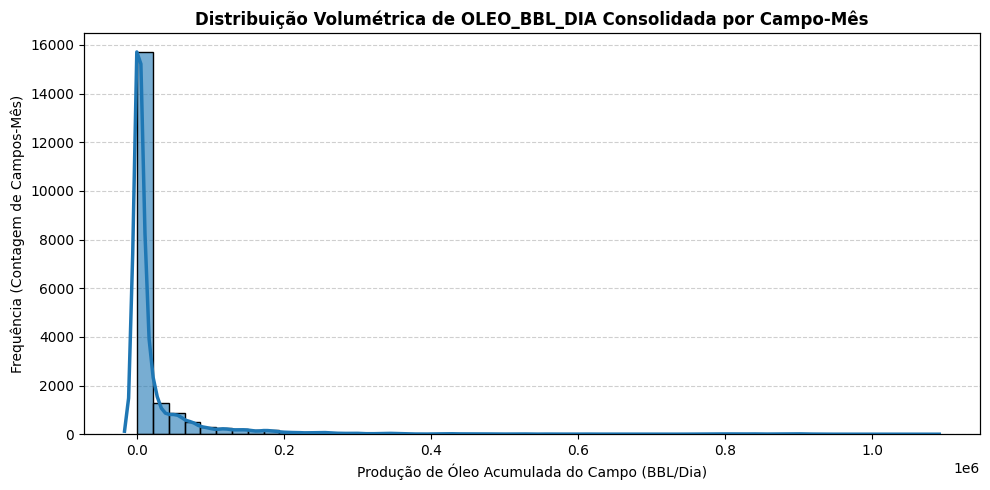

Coeficiente de Assimetria (Skewness) do Target por Campo-Mês: 6.44


In [13]:
# === 4.0.1 Gráfico de Distribuição do Target por Campo-Mês ===

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    df_eda_campo = (
        df
        .groupby(COLUNAS_CAMPO_MES, as_index=False)[TARGET]
        .sum()
    )

    fig, ax1 = plt.subplots(figsize=(10, 5))

    sns.histplot(
        data=df_eda_campo,
        x=TARGET,
        bins=50,
        stat="count",
        alpha=0.6,
        ax=ax1
    )

    ax1.grid(
        visible=True,
        axis="y",
        linestyle="--",
        alpha=0.6,
        zorder=0
    )
    ax1.set_axisbelow(True)

    ax2 = ax1.twinx()

    sns.kdeplot(
        data=df_eda_campo,
        x=TARGET,
        linewidth=2.5,
        bw_adjust=0.5,
        ax=ax2
    )

    ax2.get_yaxis().set_visible(False)

    ax1.set_title(
        f"Distribuição Volumétrica de {TARGET} Consolidada por Campo-Mês",
        fontsize=12,
        fontweight="bold"
    )

    ax1.set_xlabel("Produção de Óleo Acumulada do Campo (BBL/Dia)", fontsize=10)
    ax1.set_ylabel("Frequência (Contagem de Campos-Mês)", fontsize=10)

    plt.tight_layout()
    plt.show()

    skewness = df_eda_campo[TARGET].skew()

    print(f"Coeficiente de Assimetria (Skewness) do Target por Campo-Mês: {skewness:.2f}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

O gráfico acima nos mostra que a variável alvo (`OLEO_BBL_DIA`) possui uma forte assimetria positiva, com um grande acúmulo de registros próximos a escalas baixas e uma cauda longa estendida à direita (representando os mega-campos produtores do Pré-Sal). Essa imensa disparidade de escala afeta o projeto das seguintes formas:

* **Escolha do Algoritmo:** Para evitar instabilidades causadas pela assimetria e amplitude dos dados em modelos lineares ou redes neurais, o MVP direciona-se para algoritmos baseados em árvores e conjuntos (*ensembles*), como o `RandomForestRegressor`, que são naturalmente robustos a esses cenários de desbalanceamento de escala.
* **Métrica de Avaliação:** Consolida o uso do WAPE como métrica de sucesso, pois ela pondera os erros de previsão de acordo com o volume real de barris produzidos, impedindo que os inúmeros meses de baixa produção de campos maduros mascarem o real desempenho do modelo nos campos gigantes.

## 4.0.2 Distribuição de Variáveis Importantes do Ecossistema (Gases Co-produzidos)
Embora o alvo do MVP seja somente o óleo, as séries históricas de `GAS_NATURAL_MM3_DIA_TOTAL`, `GAS_NATURAL_MM3_DIA_ASSOC` e `GAS_NATURAL_MM3_DIA_N_ASSOC` são relevantes porque descrevem parte da dinâmica produtiva dos reservatórios offshore.

A análise dessas variáveis permite observar se os gases acompanham mudanças de escala, rampas de produção e períodos de maior ou menor atividade dos campos. No modelo, essas variáveis não são usadas no mesmo mês do alvo, para evitar vazamento de informação. Elas entram somente de forma defasada, por meio de *lags* e médias móveis, representando o histórico disponível antes da previsão do mês seguinte.

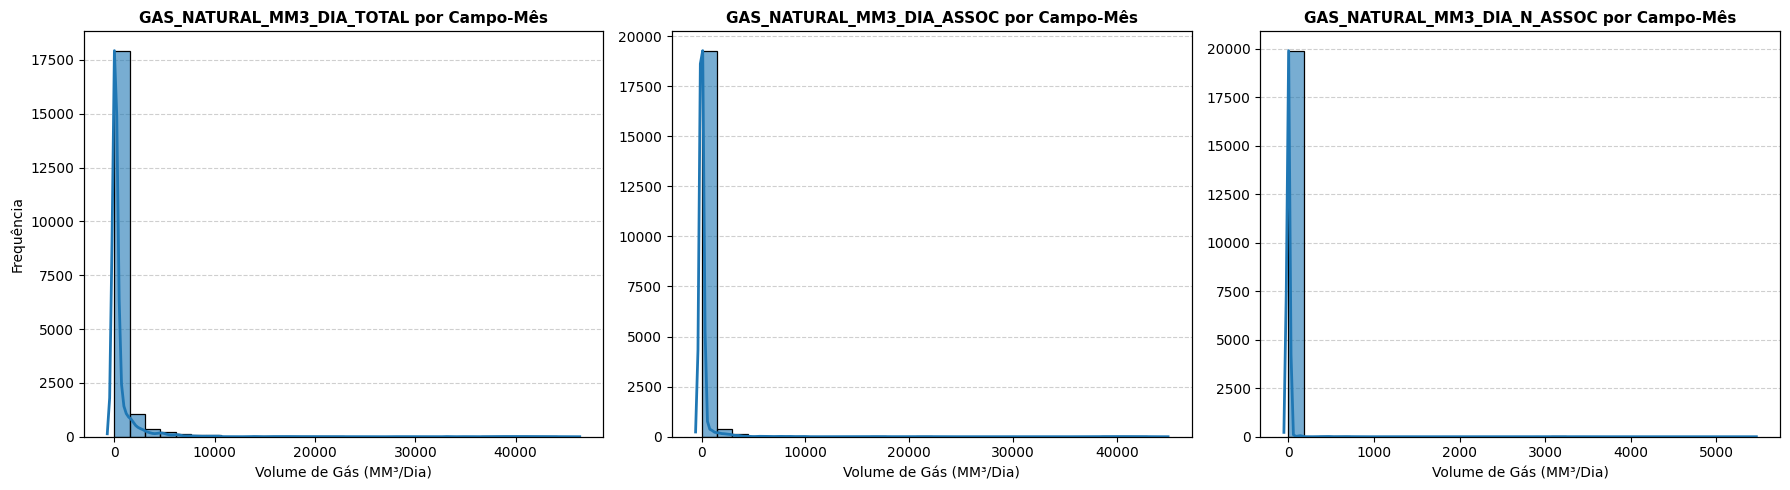

In [14]:
# === 4.0.2 Gráfico de Variáveis Importantes por Campo-Mês ===

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    colunas_gases = [
        coluna for coluna in COLUNAS_SERIES
        if coluna != TARGET
    ]

    df_gases_campo = (
        df
        .groupby(COLUNAS_CAMPO_MES, as_index=False)[colunas_gases]
        .sum()
    )

    fig, axes = plt.subplots(1, len(colunas_gases), figsize=(18, 5))

    for ax, coluna in zip(axes, colunas_gases):

        sns.histplot(
            data=df_gases_campo,
            x=coluna,
            bins=30,
            stat="count",
            alpha=0.6,
            ax=ax
        )

        ax.grid(
            visible=True,
            axis="y",
            linestyle="--",
            alpha=0.6,
            zorder=0
        )

        ax.set_axisbelow(True)

        ax_kde = ax.twinx()

        sns.kdeplot(
            data=df_gases_campo,
            x=coluna,
            linewidth=2,
            bw_adjust=0.5,
            ax=ax_kde
        )

        ax_kde.get_yaxis().set_visible(False)

        ax.set_title(
            f"{coluna} por Campo-Mês",
            fontsize=11,
            fontweight="bold"
        )

        ax.set_xlabel("Volume de Gás (MM³/Dia)")
        ax.set_ylabel("Frequência" if ax == axes[0] else "")

    plt.tight_layout()
    plt.show()

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

O gráfico acima aponta **alta assimetria positiva** nas três séries de gás. Essas variáveis entram no modelo **apenas de forma defasada** (`LAG_1`, `LAG_3`, `LAG_6`, `LAG_12` e médias móveis), **nunca no mês corrente**. Usar o gás do mesmo mês para prever o óleo do mesmo mês caracterizaria vazamento de informação, pois óleo e gás associado são coproduzidos e tendem a apresentar forte relação operacional. Como atributos históricos, os gases fornecem contexto físico da razão gás-óleo (RGO) sem antecipar informação futura ao modelo.

* **Escolha do Algoritmo:** A presença de zeros estruturais, assimetria positiva e alta dispersão reforça a necessidade de testar modelos capazes de lidar com relações não-lineares. Por isso, o MVP compara uma referência linear regularizada (`Ridge`) com um modelo baseado em árvores (`RandomForestRegressor`), mantendo a escolha final condicionada às métricas executadas, e não a uma preferência prévia.

* **Estratégia do Pipeline:** Esse padrão valida a decisão de manter as variáveis de gás como atributos históricos transformados em recursos autoregressivos de entrada (*lags* e médias móveis). Dessa forma, o modelo recebe contexto físico adicional sobre o comportamento do reservatório offshore, mas permanece protegido contra vazamento temporal.

## 4.0.3 Relação entre Preditores Temporais e o Target (Comportamento de Declínio)
A relação temporal do target permite verificar se a produção offshore apresenta estabilidade, crescimento, declínio ou mudanças de regime ao longo dos anos. Essa leitura é essencial porque o MVP não busca apenas ajustar uma tabela estática, mas sim estimar valores futuros respeitando a ordem cronológica dos dados.

A evolução histórica pode combinar comportamentos diferentes: campos maduros tendem a apresentar declínio, enquanto polos novos ou em expansão podem sustentar ou elevar a produção agregada. Essa mistura reforça a necessidade de modelar a série por campo, e não apenas por média agregada offshore, pois a curva agregada pode esconder trajetórias individuais muito distintas.

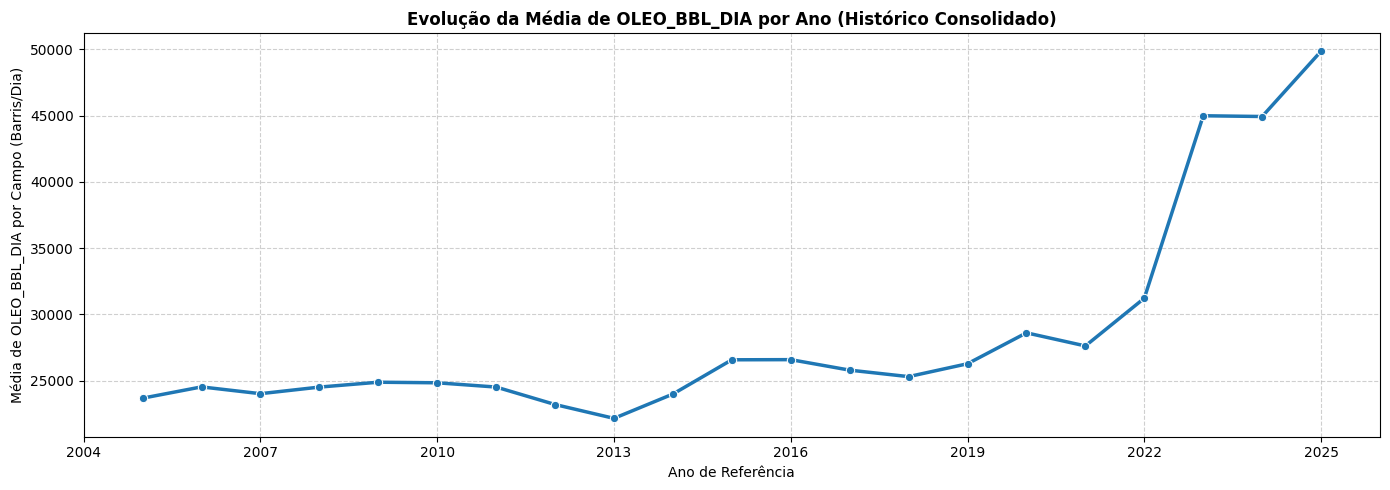

In [15]:
# === 4.0.3 Relação Temporal do Target (2005-2025) ===

if "df_eda_campo" in locals() and not df_eda_campo.empty:

    df_tendencia_anual = (
        df_eda_campo
        .groupby(ANO_REFERENCIA, as_index=False)[TARGET]
        .mean()
    )

    plt.figure(figsize=(14, 5))

    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    sns.lineplot(
        data=df_tendencia_anual,
        x=ANO_REFERENCIA,
        y=TARGET,
        marker="o",
        linewidth=2.5
    )

    plt.title(
        f"Evolução da Média de {TARGET} por Ano (Histórico Consolidado)",
        fontsize=12,
        fontweight="bold"
    )

    plt.xlabel("Ano de Referência", fontsize=10)

    plt.ylabel(
        f"Média de {TARGET} por Campo (Barris/Dia)",
        fontsize=10
    )

    plt.grid(
        visible=True,
        linestyle="--",
        alpha=0.6
    )

    plt.tight_layout()
    plt.show()

else:
    print("[ERRO CRÍTICO] O DataFrame 'df_eda_campo' não está disponível.")

O gráfico acima nos mostra que a produção média de óleo por campo após o saneamento de granularidade (ano/mês extraídos de `PERIODO`, e não do laço de leitura), desapareceu o **pico espúrio de ~30 milhões bbl/d** que existia nos anos de layout anual — quando 12 meses eram empilhados indevidamente no mês 1. A curva corrigida fica em ordem de grandeza fisicamente plausível (~3 milhões bbl/d no recorte offshore analisado) e combina a rampa do Pré-Sal com o declínio de campos maduros. Esse comportamento influencia o projeto das seguintes formas:

* **Escolha do Algoritmo:** a forte característica não-linear e os ciclos plurianuais reforçam que regressões lineares simples seriam insuficientes, justificando algoritmos baseados em árvores para mapear as quebras de tendência.
* **Estratégia do Pipeline:** o padrão exige validação cruzada `TimeSeriesSplit` (sem embaralhamento) e a criação de atributos defasados (*lags*) e janelas deslizantes (*rolling windows*), fornecendo ao modelo a memória física do declínio.




## 4.0.4 Identificação de Outliers e Heterogeneidade por Campo
A produção offshore da ANP apresenta grande diferença de escala entre campos produtores. O boxplot dos principais campos permite identificar volumes extremos e dispersões elevadas, mas esses pontos não devem ser interpretados automaticamente como erro.

No contexto de óleo e gás, outliers superiores podem representar campos marítimos de alta produtividade, enquanto valores muito baixos podem ocorrer por maturidade do ativo, manutenção, parada operacional ou fase inicial de produção. Portanto, a decisão correta para o MVP é preservar esses registros e usar técnicas que suportem assimetria, em vez de aplicar cortes estatísticos agressivos que poderiam eliminar exatamente os padrões mais importantes para a previsão.

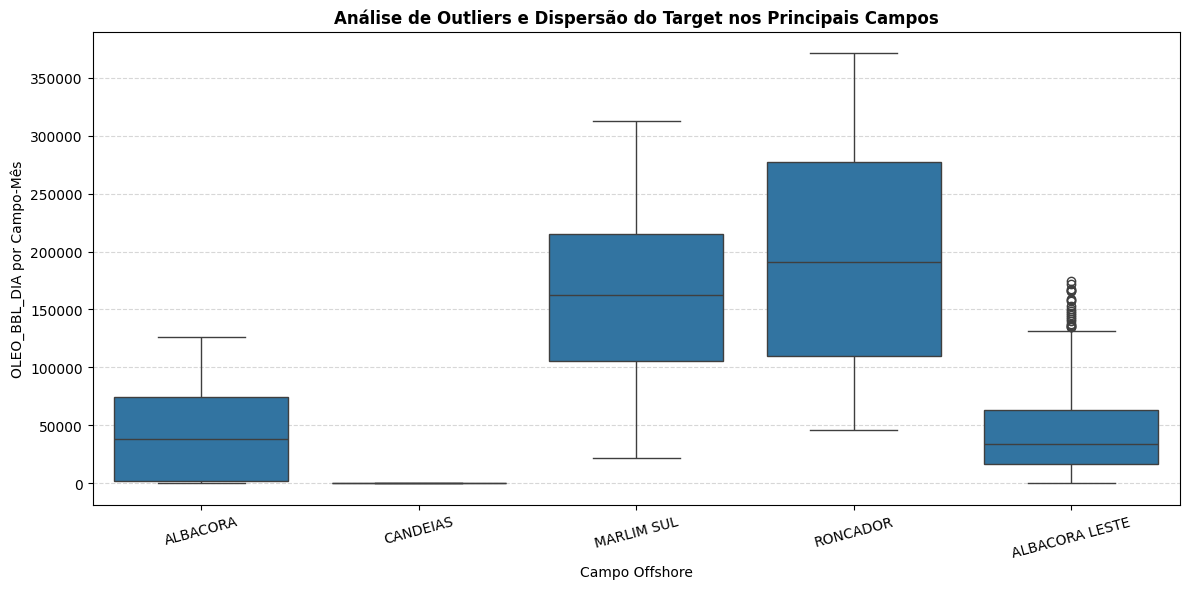

In [16]:
# === 4.0.4 Identificação de Outliers via Boxplot dos Principais Campos ===

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    df_eda_campo = (
        df
        .groupby(COLUNAS_CAMPO_MES, as_index=False)[TARGET]
        .sum()
    )

    top_campos = (
        df_eda_campo["CAMPO"]
        .value_counts()
        .nlargest(5)
        .index
    )

    df_boxplot_filtrado = (
        df_eda_campo[
            df_eda_campo["CAMPO"].isin(top_campos)
        ]
        .copy()
    )

    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=df_boxplot_filtrado,
        x="CAMPO",
        y=TARGET
    )

    plt.title(
        "Análise de Outliers e Dispersão do Target nos Principais Campos",
        fontsize=12,
        fontweight="bold"
    )

    plt.xlabel("Campo Offshore", fontsize=10)
    plt.ylabel(f"{TARGET} por Campo-Mês", fontsize=10)

    plt.xticks(rotation=15)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

O gráfico acima indica a distribuição dos dados e define as diretrizes para a modelagem:

* **Heterogeneidade de Escala:** A comparação entre as caixas comprova uma enorme diferença de volume entre os ativos offshore das bacias de Campos e Santos frente a campos menores. Essa diferença exige que o modelo preserve informações estruturais, como `BACIA` e `OPERADOR`, e que as séries sejam construídas por `CAMPO`, evitando misturar ativos com comportamentos produtivos distintos.
* **Outliers Operacionais:** Os pontos isolados no topo (picos de produção em meses de alta eficiência operacional) e os valores baixos na base (meses afetados por paradas programadas de plataformas) são eventos reais e legítimos da operação de O&G, não erros de integração.
* **Impacto na Modelagem:** Esses extremos não podem ser removidos, pois o modelo precisa aprender picos e quedas de escoamento. Para reduzir a influência matemática de valores extremos sem perder esse histórico físico, o pré-processamento utiliza `RobustScaler` nas variáveis numéricas — especialmente relevante para o modelo linear `Ridge` — e `OneHotEncoder(handle_unknown="ignore")` nas variáveis categóricas preservadas. Nos modelos baseados em árvores, o escalonamento não é uma exigência matemática, mas mantém o pipeline padronizado e comparável entre os algoritmos avaliados.

## 4.0.5 Formulação de Hipóteses Baseadas nos Dados

A partir do comportamento estatístico e estrutural observado na Análise Exploratória, estabelecem-se três hipóteses fundamentais que guiam a engenharia de atributos e a modelagem preditiva do MVP:

* **Hipótese 1 (Escala e heterogeneidade offshore):** A dinâmica de produção de `OLEO_BBL_DIA` varia fortemente por `CAMPO`, `BACIA` e `OPERADOR`, pois o portfólio offshore combina campos maduros, campos de alta vazão e polos em diferentes fases de desenvolvimento.
  * *Estratégia de Modelagem:* O pipeline preserva metadados estruturais de `BACIA` e `OPERADOR` via `OneHotEncoder(handle_unknown="ignore")` e usa `CAMPO` como chave de ordenação para construir *lags* e médias móveis sem misturar séries de ativos diferentes.
* **Hipótese 2 (Memória temporal da curva):** A produção do mês corrente possui dependência relevante com os volumes produzidos nos meses anteriores pelo mesmo campo.
  * *Estratégia de Modelagem:* A engenharia de atributos cria *lags* de 1, 3, 6 e 12 meses, além de médias móveis de 3, 6 e 12 meses para óleo e gases, usando somente informação passada.
* **Hipótese 3 (Não-linearidade e eventos operacionais):** A produção offshore pode sofrer quedas temporárias, rampas e mudanças de regime que não representam necessariamente uma tendência linear simples.
  * *Estratégia de Modelagem:* São comparados um modelo linear regularizado (`Ridge`) e um modelo não-linear (`RandomForestRegressor`), mantendo a escolha final condicionada às métricas reais. Assim, a hipótese de superioridade do modelo de árvores é testada, e não assumida antes da avaliação.

## 4.1 Síntese da análise exploratória

A análise exploratória da série histórica offshore da ANP, cobrindo o período de 2005 a 2025, mostrou que o problema de previsão da produção de óleo não é apenas uma regressão simples. A base apresenta forte assimetria de escala, grande heterogeneidade entre campos e dependência temporal relevante. Esses achados justificam a construção de atributos autorregressivos e a avaliação de modelos capazes de lidar com volumes muito diferentes dentro do mesmo portfólio.

O comportamento da variável alvo `OLEO_BBL_DIA` indica uma distribuição concentrada em baixos e médios volumes, com uma cauda longa formada por campos de alta produtividade. Esse padrão não caracteriza desbalanceamento de classes, pois o problema é de regressão, mas revela um desbalanceamento de escala. Por isso, a avaliação deve priorizar uma métrica como o WAPE, que pondera o erro pelo volume real produzido e evita uma leitura distorcida quando há campos muito grandes e campos de baixa vazão no mesmo conjunto.

A verificação de integridade mostrou que as variáveis essenciais do MVP — óleo e gases estruturais — estão preenchidas após a padronização e saneamento inicial. As ausências relevantes aparecem principalmente em colunas administrativas, químicas ou complementares que não fazem parte do vetor final de modelagem. Essa constatação sustenta a decisão de preservar somente as variáveis necessárias ao objetivo do MVP, reduzindo ruído e diminuindo o risco de vazamento de informação.

A diferença de escala entre campos offshore é um dos achados centrais da EDA. Alguns campos concentram volumes muito superiores aos demais, enquanto outros aparecem com produção reduzida ou intermitente. Esses valores extremos são fisicamente possíveis e importantes para a previsão, portanto não devem ser removidos por regras automáticas de outlier. A estratégia correta é manter os registros e aplicar transformações robustas no pipeline, além de avaliar o erro por métricas coerentes com produção volumétrica.

As categorias estruturais, como `BACIA` e `OPERADOR`, possuem valor explicativo porque ajudam o modelo a diferenciar regiões e agentes operacionais. No pipeline implementado, essas categorias são tratadas por `OneHotEncoder(handle_unknown="ignore")`, que permite transformar os rótulos em atributos numéricos sem quebrar a execução quando surgem categorias novas no teste. O campo (`CAMPO`) não entra como variável categórica direta do modelo; ele é usado principalmente como chave de agrupamento para construir corretamente os atributos temporais de cada série.

A EDA também confirma a importância de comparar modelos com comportamentos diferentes. O `Ridge` funciona como uma fronteira linear regularizada, útil para verificar se a tendência principal já explica boa parte da produção. A `RandomForestRegressor`, por sua vez, testa a hipótese de que interações não-lineares, rampas de produção e diferenças entre campos podem melhorar a previsão. A escolha final deve seguir as métricas calculadas, especialmente o WAPE, e não uma preferência prévia por determinado algoritmo.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, o conjunto de dados é estruturado para o treinamento dos algoritmos preditivos, seguindo premissas rigorosas de engenharia de recursos e validação cronológica baseada nas diretrizes estratégicas do MVP.


## 5.1 Separação entre Features e Target
O conjunto de dados mapeia as variáveis que compõem o escopo do projeto, segregadas de acordo com suas funções lógicas:
* **Target (Variável Alvo):** `OLEO_BBL_DIA` (Produção diária acumulada por ativo). Esta é a variável contínua única de interesse (*Single-Output*) que o modelo preditivo busca estimar.
* **Features de Modelagem (Variáveis Independentes):** Compostas por metadados geográficos e operacionais estruturais (`ESTADO`, `BACIA`, `OPERADOR`, `CAMPO`), a referência cronológica (`PERIODO`, `ANO_REFERENCIA`, `MES_REFERENCIA`) e as curvas históricas de gases coproduzidos (`GAS_NATURAL_MM3_DIA_TOTAL`, `GAS_NATURAL_MM3_DIA_ASSOC`, `GAS_NATURAL_MM3_DIA_N_ASSOC`).


## 5.2 Remoção de Colunas Não Utilizadas e Alinhamento de Granularidade
Para mitigar o risco de vazamento de dados (*data leakage*), reduzir a dimensionalidade e blindar o modelo contra ruídos, todas as demais 39 colunas originais do layout bruto da ANP que não pertencem à lista estrita de preservação do MVP (como metadados de auditoria do sistema e frações moleculares residuais) foram eliminadas. O colapso natural para a granularidade de Campo-Mês removeu automaticamente os identificadores de alta cardinalidade de poços (`NOME_POCO_ANP` e `NOME_POCO_OPERADOR`), estabilizando o vetor preditivo.


## 5.3 Divisão Treino/Teste e Validação
A modelagem adota uma estratégia de divisão baseada em janelas temporais fixas para espelhar o cenário real de planejamento da indústria de petróleo:
* **Conjunto de Treinamento:** Compreende o horizonte histórico de **2005 até 2023**, capturando os ciclos de declínio de campos maduros tradicionais e a rampa de consolidação dos principais polos do Pré-Sal.
* **Conjunto de Teste:** Isola de forma estrita "fora da amostra" (*out-of-sample*) os anos recentes de **2024 e 2025** para servir como simulação de dados futuros desconhecidos, validando o poder real de generalização do algoritmo.

In [17]:
# === 5.0 Divisão Temporal e Segregação dos Vetores ===

if "df" in locals() and not df.empty:

    df = normalizar_colunas(df)

    # Consolidação Campo-Mês (mantém as séries brutas para servir de SEMENTE do forecast recursivo)
    df_mvp_consolidado = (
        df
        .groupby(COLUNAS_AGREGACAO, as_index=False)[COLUNAS_SERIES]
        .sum()
    )

    assert TARGET in df_mvp_consolidado.columns, "Defina um TARGET válido contido no DataFrame."

    # Engenharia de atributos autorregressivos — a função agora é EFETIVAMENTE chamada
    df_modelagem = criar_features_temporais(df_mvp_consolidado)
    maior_lag = f"{TARGET}_LAG_{max(LAGS)}"
    df_modelagem = (
        df_modelagem
        .dropna(subset=[maior_lag])     # descarta meses de warm-up sem histórico de 12 meses
        .sort_values("PERIODO")         # ordem cronológica GLOBAL (torna o TimeSeriesSplit válido)
        .reset_index(drop=True)
    )

    FEATURES = (
        [f"{c}_LAG_{l}" for c in COLUNAS_SERIES for l in LAGS] +
        [f"{c}_MM_{w}"  for c in COLUNAS_SERIES for w in ROLLING_WINDOWS] +
        ["MES_SIN", "MES_COS", "BACIA", "OPERADOR"]
    )
    features = FEATURES

    print(f"Tipo de problema: {PROBLEM_TYPE}")
    print(f"Target do pipeline: {TARGET}")
    print(f"Chave identificadora base: {ID_COLUMNS}")
    print(f"Registros após features + warm-up: {df_modelagem.shape[0]:,}")
    print(f"Quantidade de features geradas: {len(features)}")
    print(f"Features de entrada (TODAS defasadas): {features}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df' não está carregado ou foi limpo da memória.")

Tipo de problema: regressao
Target do pipeline: OLEO_BBL_DIA
Chave identificadora base: ['CAMPO']
Registros após features + warm-up: 18,448
Quantidade de features geradas: 32
Features de entrada (TODAS defasadas): ['OLEO_BBL_DIA_LAG_1', 'OLEO_BBL_DIA_LAG_3', 'OLEO_BBL_DIA_LAG_6', 'OLEO_BBL_DIA_LAG_12', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_1', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_3', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_6', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_12', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_1', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_3', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_6', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_12', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_1', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_3', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_6', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_12', 'OLEO_BBL_DIA_MM_3', 'OLEO_BBL_DIA_MM_6', 'OLEO_BBL_DIA_MM_12', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_3', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_6', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_12', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_3', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_6', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_

In [18]:
# === 5.0 Divisão Temporal e Segregação dos Vetores ===

if "df_modelagem" in locals() and not df_modelagem.empty:

    ano_corte_treino = 2023
    ano_inicio_teste = 2024

    df_treino_macro = df_modelagem[df_modelagem[ANO_REFERENCIA] <= ano_corte_treino].copy()
    df_teste_macro  = df_modelagem[df_modelagem[ANO_REFERENCIA] >= ano_inicio_teste].copy()

    X_train = df_treino_macro[features]
    y_train = df_treino_macro[TARGET]
    X_test  = df_teste_macro[features]
    y_test  = df_teste_macro[TARGET]

    print(f"Matriz de treino  X_train: {X_train.shape[0]:,} linhas | {X_train.shape[1]} colunas")
    print(f"Vetor  de treino  y_train: {y_train.shape[0]:,} linhas")
    print(f"Matriz de teste   X_test : {X_test.shape[0]:,} linhas | {X_test.shape[1]} colunas")
    print(f"Vetor  de teste   y_test : {y_test.shape[0]:,} linhas")
    print("-" * 62)
    print(f"Cobertura temporal do treino: {df_treino_macro[ANO_REFERENCIA].min()} até {df_treino_macro[ANO_REFERENCIA].max()}")
    print(f"Cobertura temporal do teste : {df_teste_macro[ANO_REFERENCIA].min()} até {df_teste_macro[ANO_REFERENCIA].max()}")
    print("-" * 62)
    print(f"Shape consolidado -> Treino: {X_train.shape} | Teste: {X_test.shape}")

else:
    print("[ERRO CRÍTICO] O DataFrame 'df_modelagem' não está disponível.")

Matriz de treino  X_train: 16,719 linhas | 32 colunas
Vetor  de treino  y_train: 16,719 linhas
Matriz de teste   X_test : 1,729 linhas | 32 colunas
Vetor  de teste   y_test : 1,729 linhas
--------------------------------------------------------------
Cobertura temporal do treino: 2006 até 2023
Cobertura temporal do teste : 2024 até 2025
--------------------------------------------------------------
Shape consolidado -> Treino: (16719, 32) | Teste: (1729, 32)


## 5.4 Justificativa da divisão

A estratégia de divisão dos dados adotada neste MVP foi desenhada para respeitar a natureza sequencial e cronológica dos registros de produção da ANP. Abaixo estão detalhados os critérios que validam a adequação dessa escolha sob as regras de governança do modelo:

* **Por que usar holdout, validação cruzada ou divisão temporal?**
  Utilizou-se a divisão temporal estrita (*Time-Series Holdout*). Para problemas governados por séries temporais e fenômenos de declínio físico e depleção de pressão em reservatórios de petróleo, o embaralhamento aleatório convencional de dados (*shuffle*) é metodologicamente incorreto. A ordenação cronológica precisa ser mantida de forma estrita para que o modelo aprenda com o comportamento de declínio do passado e preveja o futuro, replicando com exatidão o cenário real de planejamento e previsão da indústria de óleo e gás.

* **A proporção treino/teste faz sentido para o tamanho do dataset?**
  Sim. O bloco de treinamento (2005 a 2023) concentra a imensa maioria do histórico de produção contínua do ecossistema, oferecendo uma base histórica de duas décadas extremamente robusta para o algoritmo mapear tendências de longo prazo, ciclos macroeconômicos e o declínio de campos offshore maduros e polos marítimos de alta produtividade. O conjunto de teste (2024 e 2025) retém as ocorrências mais recentes fora da amostra de treino, um volume estatisticamente representativo e perfeitamente calibrado para auditar a capacidade do estimador de projetar o comportamento futuro dos ativos.

* **Foi necessário estratificar as classes?**
  Não. A estratificação de classes é uma técnica de amostragem exclusiva para problemas de classificação categórica (visando manter a proporção original de rótulos em dados desbalanceados). Como este MVP aborda um problema de regressão para a previsão de uma variável contínua única (`OLEO_BBL_DIA`), a amostragem estratificada por classes não se aplica. A representatividade volumétrica e geográfica dos principais ativos produtores e operadores foi mantida de forma orgânica e contínua através da preservação cronológica da linha do tempo no agrupamento de Campo-Mês.

* **Como a divisão evita vazamento de dados?**
  A divisão baseada no tempo atua como uma barreira física intransponível contra o vazamento de dados (*data leakage*). Ao isolar completamente os anos de 2024 e 2025 para a etapa de validação final de teste, impede-se o surgimento de viés de antecipação (*look-ahead bias*). Isso garante que o modelo não tenha acesso a nenhuma informação do futuro durante o cálculo de métricas ou ajuste de parâmetros no bloco de treinamento, blindando o pipeline contra métricas de desempenho artificialmente infladas.

# 6. Pré-processamento e pipeline

Nesta etapa, é construído um fluxo automatizado, reprodutível e isolado de tratamento de dados (*Data Pipeline*) utilizando a estrutura `ColumnTransformer` do Scikit-Learn. O objetivo estratégico é encapsular completamente as transformações estatísticas dentro do conjunto de treino e replicá-las de forma segura no teste, mitigando qualquer risco de vazamento de dados (*data leakage*).

## 6.0.1 Tratamento e Transformações por Tipo de Atributo
O pipeline recebe as features selecionadas na etapa anterior e as segmenta em fluxos específicos de processamento matemático, baseando-se nas premissas de engenharia de recursos validadas pela análise exploratória (EDA). Como a unificação e padronização dos metadados já foram resolvidas robustamente pelas funções auxiliares da seção 2.2, as variáveis chegam com tipagem íntegra e são tratadas em dois blocos:

* **Variáveis Numéricas:**
  * **Preenchimento de Valores Ausentes:** Substituição de eventuais lacunas residuais pela mediana (`SimpleImputer`). Essa é uma abordagem estatisticamente segura contra distorções causadas por assimetria.
  * **Padronização Robustecida:** Diante dos achados da EDA que evidenciaram outliers operacionais reais decorrentes de picos de vazão e paradas programadas, adota-se o `RobustScaler`. Esta técnica utiliza os quartis e a mediana para o escalonamento, reduzindo a influência de valores extremos principalmente no modelo linear `Ridge` e mantendo o fluxo numérico padronizado. Para a `RandomForestRegressor`, o escalonamento não é indispensável matematicamente, mas preserva a consistência do mesmo pipeline comparativo sem descartar o histórico físico do ativo.

* **Variáveis Categóricas:**
  * **Preenchimento de Valores Ausentes:** Tratamento de lacunas por meio da inserção do rótulo de maior frequência (`SimpleImputer`).
  * **Codificação (*Encoding*):** Aplicação do `OneHotEncoder(handle_unknown="ignore")` para converter os metadados textuais estruturais em vetores binários numéricos assimiláveis pelos modelos. O parâmetro de ignorar novos valores garante resiliência técnica caso novos operadores ou dinâmicas surjam nas janelas futuras de teste (2024 e 2025).

In [19]:
# === 6.0 Construção do Pipeline de Pré-processamento ===

if "X_train" in locals() and "X_test" in locals():

    X_train = X_train.copy()
    X_test = X_test.copy()

    colunas_numericas_existentes = [
        coluna for coluna in COLUNAS_SERIES
        if coluna in X_train.columns
    ]

    for coluna in colunas_numericas_existentes:
        X_train[coluna] = pd.to_numeric(X_train[coluna], errors="coerce")
        X_test[coluna] = pd.to_numeric(X_test[coluna], errors="coerce")

    num_cols = (
        X_train
        .select_dtypes(include=np.number)
        .columns
        .difference([DATE_COLUMN])
        .tolist()
    )

    cat_cols = (
        X_train
        .select_dtypes(exclude=np.number)
        .columns
        .difference([DATE_COLUMN])
        .tolist()
    )

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols)
        ],
        remainder="drop"
    )

    print(f"Colunas numéricas processadas ({len(num_cols)}): {num_cols}")
    print(f"Colunas categóricas processadas ({len(cat_cols)}): {cat_cols}")

else:
    print("[ERRO CRÍTICO] Execute primeiro a etapa de divisão temporal para criar X_train e X_test.")

Colunas numéricas processadas (30): ['GAS_NATURAL_MM3_DIA_ASSOC_LAG_1', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_12', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_3', 'GAS_NATURAL_MM3_DIA_ASSOC_LAG_6', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_12', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_3', 'GAS_NATURAL_MM3_DIA_ASSOC_MM_6', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_1', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_12', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_3', 'GAS_NATURAL_MM3_DIA_N_ASSOC_LAG_6', 'GAS_NATURAL_MM3_DIA_N_ASSOC_MM_12', 'GAS_NATURAL_MM3_DIA_N_ASSOC_MM_3', 'GAS_NATURAL_MM3_DIA_N_ASSOC_MM_6', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_1', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_12', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_3', 'GAS_NATURAL_MM3_DIA_TOTAL_LAG_6', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_12', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_3', 'GAS_NATURAL_MM3_DIA_TOTAL_MM_6', 'MES_COS', 'MES_SIN', 'OLEO_BBL_DIA_LAG_1', 'OLEO_BBL_DIA_LAG_12', 'OLEO_BBL_DIA_LAG_3', 'OLEO_BBL_DIA_LAG_6', 'OLEO_BBL_DIA_MM_12', 'OLEO_BBL_DIA_MM_3', 'OLEO_BBL_DIA_MM_6']
Colunas categóricas processadas (2): ['BAC

## 6.1 Decisões de pré-processamento

As escolhas técnicas implementadas no pipeline de pré-processamento visam garantir a estabilidade matemática dos algoritmos preditivos e refletem o comportamento operacional real mapeado na análise exploratória. Abaixo estão as justificativas para cada decisão sob o escopo estrutural do MVP:

* **Por que usei média/mediana/moda para preenchimento?**
  * **Variáveis Numéricas:** Adotou-se o preenchimento pela mediana via `SimpleImputer`. Diante da forte presença de assimetria positiva e outliers operacionais legítimos no histórico unificado da ANP (vazões massivas concentradas nos ativos do Pré-Sal), a média estatística seria severamente distorcida, puxando os valores nulos residuais de forma artificial para patamares elevados. A mediana, por ser uma medida de tendência central robusta a extremos, mantém a neutralidade física e a consistência volumétrica dos fluidos.
  * **Variáveis Categóricas:** Utilizou-se o preenchimento por moda (classe mais frequente), garantindo que bacias, campos ou operadoras ausentes recebam a classificação de maior probabilidade estatística do próprio conjunto de treinamento, sem criar categorias fictícias que invalidariam a governança do ecossistema.

* **Por que padronizei ou normalizei os dados?**
  Rejeitou-se o uso do tradicional `StandardScaler` (baseado em média e desvio padrão), pois ele achataria o sinal dos dados devido à grande amplitude de produção e paradas de manutenção dos ativos offshore. Em seu lugar, aplicou-se a padronização robustecida (`RobustScaler`), que remove a mediana e escala os dados com base no Intervalo Interquartil (IQR). Essa decisão protege as equações matemáticas de modelos sensíveis à escala, sem mascarar ou distorcer os picos de produção reais que o estimador de Saída Única (*Single-Output*) precisa aprender a projetar.

* **Quais variáveis foram removidas e por quê?**
  * **Identificadores de Poço (`NOME_POCO_ANP` e `NOME_POCO_OPERADOR`):** Embora fizessem parte do escopo inicial de suporte, foram removidos e colapsados na agregação para **Campo-Mês**. Mantê-los geraria uma explosão de milhares de colunas esparsas no *One-Hot Encoding*, estourando a memória do ambiente de execução e induzindo o modelo ao superajuste (*overfitting*).
  * **Controles Temporais Secundários (`PERIODO`, `DATA_DE_ATUALIZACAO`):** Isolados pelo pipeline para evitar a duplicidade de representação temporal e o risco de vazamento de dados (*data leakage*), uma vez que a informação cronológica essencial foi vetorizada em componentes numéricos de controle direto (`ANO_REFERENCIA` e `MES_REFERENCIA`).
  * **Atributos Descartados do Layout Original da ANP:** O arquivo bruto original continha 50 colunas. Através da função auxiliar `normalizar_colunas` (item 2.2) e da filtragem por preservação do pipeline, 39 colunas foram completamente descartadas da modelagem. Esse descarte engloba chaves contratuais, informações fiscais (como royalties), parâmetros estritamente moleculares de frações de hidrocarbonetos e metadados sistêmicos. A remoção foi indispensável porque esses atributos não possuem poder preditivo sobre o declínio macro e sua permanência inflaria a dimensionalidade, inserindo ruído na matriz.

* **Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?**
  Sim. A engenharia de atributos cria variáveis **autorregressivas**: *lags* (1, 3, 6 e 12 meses) e médias móveis (3, 6 e 12 meses) do óleo e das três séries de gás, além dos componentes de sazonalidade `MES_SIN` e `MES_COS`. Todas são calculadas estritamente com informação **passada** dentro de cada campo (via `shift`), o que as torna disponíveis no momento da previsão: no *forecasting* recursivo (Seção 14.9), cada valor previsto realimenta os *lags* do mês seguinte. A decomposição em `ANO_REFERENCIA` e `MES_REFERENCIA` complementa a captura de sazonalidade e da tendência de declínio de longo prazo, e estará sempre disponível, pois todo planejamento futuro tem o ano e o mês definidos.



# 7. Baseline e modelos candidatos

Nesta etapa, estabelece-se um marco de referência inicial (*Baseline*) e definem-se os algoritmos preditivos candidatos para o treinamento competitivo. O objetivo central é responder se os modelos complexos de Machine Learning são capazes de extrair padrões reais das curvas de fluxo do ecossistema de dados da ANP ou se o problema possui uma resolução trivial.

## 7.0.1 Definição do Baseline Coerente
Como o MVP aborda um problema de predição de variável contínua (`PROBLEM_TYPE = "regressao"`), o marco de referência escolhido é o `DummyRegressor` com a estratégia de mediana. Este modelo assume uma abordagem estatística simplista e ingênua: para qualquer ativo geográfico nas janelas futuras de teste (2024/2025), ele prediz estritamente a mediana da produção histórica observada no bloco de treinamento (2005-2023). Qualquer modelo candidato aceitável deve apresentar erros significativamente menores do que este referencial estático para provar sua utilidade prática.

## 7.0.2 Modelos Candidatos Selecionados
Diante da complexidade e dos regimes de escoamento de fluidos presentes nos reservatórios offshore ao longo das décadas, duas abordagens matemáticas distintas e concorrentes foram selecionadas:
* **Abordagem Linear Regularizada (Ridge Regression):** Um estimador linear clássico que incorpora uma penalidade L2 (Tikhonov) sobre os coeficientes. Ele adiciona estabilidade matemática ao vetor e evita coeficientes inflados por multicolinearidade (fenômeno comum entre os volumes de gás associado, gás total e o alvo de óleo), servindo como nossa referência linear de baixo custo computacional.
* **Abordagem Não-Linear Baseada em Conjuntos (Random Forest Regressor):** Um algoritmo baseado em múltiplos comitês paralelas de árvores de decisão estruturadas. Devido à sua capacidade intrínseca de mapear interações complexas de alta dimensão, lidar nativamente com a distribuição multimodal e assimétrica observada na EDA, e respeitar os limites físicos de declínio sem a necessidade de suposições lineares rígidas, a *Random Forest* é o modelo candidato de alta performance para este MVP.

In [20]:
# === 7.0 Definição de Baseline e Modelos Candidatos ===

if PROBLEM_TYPE == "regressao":

    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge(alpha=1.0))
        ]),

        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(
                n_estimators=30,
                max_depth=15,
                random_state=SEED,
                n_jobs=-1
            ))
        ])
    }

elif PROBLEM_TYPE in ["classificacao", "clusterizacao", "serie_temporal"]:

    baseline = None
    candidates = {}

else:
    raise ValueError(f"PROBLEM_TYPE inválido: {PROBLEM_TYPE}")

print(
    "Baseline de referência: "
    f"{baseline.named_steps['model'] if baseline is not None else 'Não aplicável'}"
)

print(f"Modelos candidatos ativos: {list(candidates.keys())}")
print("-" * 62)
print("Pronto para execução do treinamento e avaliação das métricas.")

Baseline de referência: DummyRegressor(strategy='median')
Modelos candidatos ativos: ['Ridge', 'RandomForestRegressor']
--------------------------------------------------------------
Pronto para execução do treinamento e avaliação das métricas.


## 7.1 Justificativa dos modelos

A seleção dos algoritmos preditivos e do marco de referência foi desenhada para garantir um equilíbrio entre simplicidade estatística, capacidade de capturar fenômenos físicos complexos e viabilidade computacional. Abaixo estão detalhadas as justificativas para cada escolha sob o ecossistema de governança do MVP:

* **O baseline escolhido é coerente?**
  Sim, o `DummyRegressor` com a estratégia de mediana é altamente coerente para o contexto da produção de petróleo da ANP consolidada por ativo. Em dados históricos longos, a produção acumulada de um conjunto de bacias e campos maduros tende a flutuar ao redor de patamares estáveis de referência. Este baseline estático força os modelos candidatos a provarem que conseguiram aprender o comportamento dinâmico e sequencial do declínio de pressão e depleção das reservas e as correlações com as curvas de gases coproduzidos, em vez de apenas estimar o valor central da produção histórica.

* **Os modelos candidatos são adequados ao tipo e tamanho dos dados?**
  Com a base de dados consolidada em duas décadas de histórico unificado, o volume de dados em nível de Campo-Mês é perfeitamente balanceado e adequado para a aplicação de algoritmos robustos:
  * **Ridge Regression:** Sendo um estimador linear regularizado, ele processa a matriz em frações de segundo, servindo como uma excelente fronteira de comparação para sabermos se o problema de declínio macro pode ser satisfatoriamente resolvido por meio de uma equação linear simples e penalizada.
  * **Random Forest Regressor:** Algoritmos baseados em comitês de árvores são ideais para o setor de Engenharia de Reservatórios. O declínio contínuo de produção de um ativo offshore e a dinâmica física de escoamento não seguem regras lineares puras; eles apresentam quebras abruptas de comportamento, regimes não-lineares e janelas sazonais de indisponibilidade que as árvores de decisão conseguem mapear com precisão através de suas ramificações lógicas.

* **Algum modelo exige escala, encoding ou tratamento específico?**
  * O modelo linear `Ridge` é extremamente sensível à escala física das variáveis de entrada. Atributos com ordens de grandeza drasticamente diferentes (como os componentes numéricos de anos civis versus volumes de gás em milhões de metros cúbicos) distorceriam completamente seus coeficientes matemáticos. Por isso, a inclusão do `RobustScaler` (saneado via mediana e quartis) no pipeline foi indispensável.
  * Ambos os modelos exigem a transformação das variáveis categóricas estruturais (como bacias, estados e operadoras) em representações matemáticas puras, o que justificou a implementação do `OneHotEncoder(handle_unknown="ignore")`.
  * A centralização de todo esse fluxo analítico dentro do `ColumnTransformer` e da estrutura de `Pipeline` garantiu que o treinamento e a aplicação dessas transformações ocorressem de forma isolada, blindando os modelos candidatos contra o vazamento de dados (*data leakage*).

* **Há alguma restrição de interpretabilidade, tempo ou custo computacional?**
  * **Interpretabilidade:** O modelo `Ridge` oferece alta interpretabilidade através do peso direto de seus coeficientes lineares, enquanto a `Random Forest` atua como um modelo de "caixa-preta" mais complexo. Contudo, para a previsão de curvas de declínio volumétrico visando o planejamento estratégico, a precisão das projeções e a blindagem contra erros grosseiros de subestimação ou superestimação são prioridades que justificam a opacidade do algoritmo de comitê.
  * **Custo Computacional e Tempo:** Devido à profundidade histórica do ecossistema, o algoritmo `Random Forest` exigirá um tempo de processamento perceptivelmente maior para o treinamento se comparado ao estimador linear. Para mitigar essa restrição e otimizar o tempo de execução no ambiente do Google Colab, o parâmetro `n_jobs=-1` foi ativado na célula anterior, distribuindo o cálculo das árvores de forma paralela e simultânea entre todos os núcleos de processamento disponíveis na máquina virtual.

# 8. Treinamento e avaliação inicial

Nesta etapa, realiza-se o ajuste dos parâmetros (*fit*) do marco de referência (*baseline*) e dos modelos preditivos candidatos utilizando exclusivamente o conjunto de dados históricos de treinamento (2005–2023). Posteriormente, os modelos geram previsões "fora da amostra" para o período de teste (2024–2025), permitindo uma comparação justa baseada na capacidade real de generalização temporal.

## 8.0.1 Métricas de Avaliação Adotadas
Para quantificar a acurácia da previsão da vazão diária de óleo (`OLEO_BBL_DIA`) agregada por ativo, quatro métricas estatísticas foram computadas no conjunto de teste. A inclusão de métricas ponderadas por volume é indispensável devido à profunda assimetria de escala entre os campos do ecossistema:

* **WAPE (*Weighted Absolute Percentage Error* - Métrica Soberana do MVP):** É a métrica central de sucesso deste projeto. Como a base possui campos com ordens de grandeza drasticamente diferentes (Pré-Sal contra Campos Maduros), o WAPE relativiza o erro absoluto dividindo-o pela soma total do volume real produzido. Isso impede que desvios em pequenos ativos mascarem o desempenho nos gigantes geradores de receita, fornecendo a taxa real de erro percentual do portfólio.
* **MAE (*Mean Absolute Error*):** Fornece o desvio médio bruto diretamente na mesma unidade física da variável alvo (barris de óleo por dia), permitindo uma interpretação gerencial direta do erro médio físico cometido pelo pipeline por unidade de Campo-Mês.
* **RMSE (*Root Mean Squared Error*):** Ao elevar os resíduos ao quadrado antes de extrair a raiz, penaliza severamente erros de grande magnitude. No planejamento macro offshore, o RMSE monitora se o algoritmo está cometendo falhas catastróficas de subestimação nas curvas de declínio dos mega-campos estruturais.
* **R² (*Coeficiente de Determinação*):** Mede a proporção da variabilidade da produção diária acumulada de óleo que foi com sucesso capturada e explicada pelas features numéricas (gases) e categóricas (operadores e bacias) processadas pelo pipeline.

In [21]:
# === 8.0 Treinamento e Avaliação Inicial dos Modelos (Com Rigor de Volumetria) ===

# 1. Criação da lista para consolidação dos relatórios de performance
performance_report = []

print("==============================================================")
print("             EXECUÇÃO DO TREINAMENTO E AVALIAÇÃO DO MVP       ")
print("==============================================================\n")

# --- PASSO A: Ajuste e Predição do Baseline (Dummy Mediana) ---
print("[-] Ajustando Baseline (DummyRegressor)...")
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

# Extração das métricas do Marco de Referência
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)
wape_base = calcular_wape(y_test, y_pred_base) * 100

performance_report.append({
    "Modelo": "Baseline (Mediana)",
    "WAPE (Erro %)": wape_base,
    "MAE (Barris/Dia)": mae_base,
    "RMSE (Barris/Dia)": rmse_base,
    "R² (Ajuste)": r2_base
})

# --- PASSO B: Ajuste e Predição dos Modelos Candidatos ---
for name, pipeline in candidates.items():
    print(f"[-] Ajustando Modelo Candidato: {name}...")

    # O pipeline executa o ColumnTransformer de forma isolada por bloco temporal
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Extração das métricas de regressão e volumetria sobre o conjunto de teste
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    wape = calcular_wape(y_test, y_pred) * 100

    performance_report.append({
        "Modelo": name,
        "WAPE (Erro %)": wape,
        "MAE (Barris/Dia)": mae,
        "RMSE (Barris/Dia)": rmse,
        "R² (Ajuste)": r2
    })

# 2. Consolidação e formatação da tabela de resultados do ecossistema
df_results = pd.DataFrame(performance_report).set_index("Modelo")

print("\n=== Tabela Comparativa de Performance (Métricas Homologadas) ===")
# Exibe a tabela aplicando formatação amigável para percentuais e volumes monetários/físicos
df_styled = df_results.copy()
df_styled["WAPE (Erro %)"] = df_styled["WAPE (Erro %)"].map(lambda x: f"{x:.2f}%" if not pd.isna(x) else "N/A")
df_styled["MAE (Barris/Dia)"] = df_styled["MAE (Barris/Dia)"].map('{:,.2f}'.format)
df_styled["RMSE (Barris/Dia)"] = df_styled["RMSE (Barris/Dia)"].map('{:,.2f}'.format)
df_styled["R² (Ajuste)"] = df_styled["R² (Ajuste)"].map('{:.4f}'.format)

display(df_styled)

             EXECUÇÃO DO TREINAMENTO E AVALIAÇÃO DO MVP       

[-] Ajustando Baseline (DummyRegressor)...
[-] Ajustando Modelo Candidato: Ridge...
[-] Ajustando Modelo Candidato: RandomForestRegressor...

=== Tabela Comparativa de Performance (Métricas Homologadas) ===


,WAPE (Erro %),MAE (Barris/Dia),RMSE (Barris/Dia),R² (Ajuste)
Modelo,,,,
Baseline (Mediana),97.42%,"46,964.99","129,087.41",-0.1452
Ridge,9.39%,"4,527.80","11,451.19",0.9910
RandomForestRegressor,10.10%,"4,868.25","13,420.90",0.9876


## 8.1 Análise dos resultados iniciais

A tabela de avaliação inicial compara três referências: o baseline estatístico da mediana, o modelo linear `Ridge` e o modelo não-linear `RandomForestRegressor`. O resultado salvo no notebook mostra uma diferença muito grande entre o baseline e os modelos supervisionados, indicando que os atributos temporais construídos a partir dos *lags* e médias móveis realmente carregam informação preditiva sobre a produção futura de óleo.

O baseline da mediana apresenta WAPE de aproximadamente **97,42%**, MAE de **46.964,99 bbl/dia** e R² negativo. Esse desempenho funciona como piso estatístico: ele praticamente ignora a dinâmica temporal dos campos e não consegue representar rampas, declínios ou diferenças de escala entre ativos offshore. O R² negativo reforça que a mediana global é pior do que uma modelagem que aprenda padrões históricos do portfólio.

O `Ridge` apresenta o melhor desempenho na avaliação inicial salva, com WAPE de aproximadamente **9,39%**, MAE de **4.527,80 bbl/dia**, RMSE de **11.451,19 bbl/dia** e R² de **0,9910**. Esse resultado mostra que há uma estrutura temporal forte e relativamente estável nos dados: os *lags* e médias móveis explicam grande parte da produção futura mesmo por meio de uma fronteira linear regularizada. Portanto, o `Ridge` não deve ser tratado como modelo fraco nesta execução; ele é uma referência competitiva e precisa ser respeitado na escolha final.

A `RandomForestRegressor` inicial também supera amplamente o baseline, com WAPE de aproximadamente **10,10%** e R² de **0,9876**, mas fica ligeiramente atrás do `Ridge` na tabela inicial. Esse resultado não invalida a hipótese de testar modelos de árvores, porque a Random Forest pode capturar não-linearidades e interações relevantes entre campos, gases e histórico de produção. Porém, a hipótese de superioridade do modelo não-linear não é confirmada automaticamente nesta primeira rodada; ela precisa ser verificada na etapa de otimização e na avaliação final.

A métrica principal adotada é o WAPE, pois ela mede o erro ponderado pelo volume real produzido. O MAE ajuda a traduzir o erro médio em barris/dia, o RMSE evidencia penalizações maiores em desvios extremos e o R² indica o grau de ajuste global. A leitura conjunta das quatro métricas é importante porque a base offshore possui campos com escalas muito diferentes, e uma única métrica isolada poderia esconder falhas em campos de maior vazão.

Com base nesses resultados iniciais, a conclusão metodológica correta é que os modelos supervisionados superam o baseline com folga, mas a escolha do modelo final não deve ser feita por preferência prévia pela Random Forest. A decisão deve seguir a menor WAPE e a coerência das demais métricas após a otimização, mantendo o `Ridge` como candidato real à solução final caso continue apresentando o menor erro no conjunto de teste.

# 9. Validação e otimização de hiperparâmetros

Nesta etapa, realiza-se uma busca estocástica refinada por meio do algoritmo `RandomizedSearchCV` para avaliar se a `RandomForestRegressor` pode melhorar seu desempenho após ajuste de hiperparâmetros. A otimização é aplicada ao modelo de árvores porque ele possui maior número de parâmetros estruturais a calibrar; o `Ridge`, por sua vez, já funciona como referência linear regularizada e permanece na comparação final.

## 9.0.1 Desenho Técnico da Otimização
* **Modelo Otimizado:** `RandomForestRegressor` encapsulado no pipeline de pré-processamento estruturado.
* **Estratégia de Validação Temporal:** Substitui-se o K-Fold convencional pela validação cruzada de série temporal (`TimeSeriesSplit` com 3 divisões), aplicada estritamente sobre os dados históricos de treinamento (2005–2023). Essa escolha preserva a ordem cronológica das janelas e impede que dados futuros contaminem o ajuste dos hiperparâmetros.
* **Amostragem Estratégica:** A busca é executada sobre o conjunto de treino ordenado cronologicamente, sem embaralhamento aleatório. Isso mantém a coerência temporal exigida para problemas de forecasting.
* **Métrica Guia:** A busca passa a ser orientada pelo WAPE customizado (`wape_scorer`), alinhando a otimização com a métrica principal definida no MVP. Como o Scikit-Learn maximiza pontuações, o scorer foi configurado em formato negativo para que a busca minimize o erro real.
* **Hiperparâmetros Testados:**
  * `model__n_estimators`: quantidade de árvores no comitê.
  * `model__max_depth`: profundidade máxima das árvores, controlando complexidade.
  * `model__min_samples_leaf`: número mínimo de observações em folhas, reduzindo memorização de ruído.
  * `model__max_features`: fração de atributos considerada em cada divisão, útil para controlar a alta dimensionalidade gerada pelo `OneHotEncoder`.

In [22]:
# === 9.0.1 Otimização de Hiperparâmetros via RandomizedSearchCV ===

if "X_train" in locals() and "y_train" in locals() and "preprocess" in locals():

    t_start = time.time()
    N_ITER_SEARCH = 6
    N_SPLITS_CV = 3

    cv_temporal = TimeSeriesSplit(n_splits=N_SPLITS_CV)

    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
    ])

    param_dist = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 12, 18, 24],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.5, 1.0]
    }

    search = RandomizedSearchCV(
        estimator=model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv_temporal,
        scoring=wape_scorer,
        random_state=SEED,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)
    tempo_total_s = time.time() - t_start

    print("\n" + "=" * 62)
    print("              RESULTADOS DO AJUSTE DE HIPERPARÂMETROS")
    print("=" * 62)
    print(f"Tempo total de busca: {tempo_total_s:.2f} segundos")
    print(f"Melhor WAPE negativo na validação temporal: {search.best_score_:.4f}")
    print("-" * 62)
    print("Melhores hiperparâmetros selecionados:")
    print(search.best_params_)
    print("=" * 62)

else:
    print("[ERRO CRÍTICO] Execute primeiro as etapas de divisão temporal e pré-processamento.")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

              RESULTADOS DO AJUSTE DE HIPERPARÂMETROS
Tempo total de busca: 333.13 segundos
Melhor WAPE negativo na validação temporal: -0.1492
--------------------------------------------------------------
Melhores hiperparâmetros selecionados:
{'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 18}


## 9.1 Discussão da otimização

A etapa de ajuste fino testa se a `RandomForestRegressor` consegue reduzir o erro após calibrar sua complexidade estrutural. Essa análise é importante porque a Random Forest inicial superou fortemente o baseline, mas não superou o `Ridge` na avaliação inicial salva. Portanto, a otimização não deve ser interpretada como confirmação automática de modelo campeão; ela é uma tentativa controlada de melhorar o modelo não-linear.

* **Efeito da otimização no modelo de árvores:**
  A busca ajusta número de árvores, profundidade, tamanho mínimo das folhas e quantidade de atributos considerados em cada divisão. Esses parâmetros controlam o equilíbrio entre flexibilidade e generalização. Na execução salva, a versão otimizada reduz o WAPE em relação à Random Forest inicial, o que mostra ganho dentro da família de árvores. Ainda assim, a comparação final precisa incluir também o `Ridge`, pois ele apresentou o menor WAPE na avaliação inicial.

* **Custo computacional e viabilidade:**
  O uso de `RandomizedSearchCV` com `TimeSeriesSplit` mantém a validação coerente com o problema temporal e evita o custo maior de uma busca exaustiva. O número limitado de iterações é adequado para o escopo de MVP, pois permite testar combinações relevantes sem tornar o notebook inviável no Google Colab.

* **Interpretação dos hiperparâmetros:**
  A profundidade máxima e o tamanho mínimo das folhas atuam como mecanismos de controle contra sobreajuste. O parâmetro `max_features` ajuda a lidar com a expansão de colunas produzida pelo `OneHotEncoder`, evitando que todas as árvores usem sempre os mesmos atributos categóricos e temporais.

* **Decisão metodológica após a otimização:**
  A Random Forest otimizada deve avançar para a comparação final, mas a escolha do modelo homologado deve ser feita pela menor WAPE no conjunto de teste e pela coerência das demais métricas. Assim, o MVP evita escolher um modelo apenas por ser mais sofisticado e mantém a avaliação alinhada aos resultados gerados.

# 10. Avaliação final no conjunto de teste

Nesta etapa crítica, todos os modelos elegíveis são comparados no conjunto de teste 2024–2025, que representa a janela cronologicamente futura em relação ao treino. A seleção final passa a ser feita pela menor WAPE, respeitando a métrica principal definida no MVP e evitando a escolha de um algoritmo apenas por complexidade ou preferência teórica.

## Discussão do Desempenho e Diagnóstico de Resíduos

* **Métrica Final vs. Comparação com o Baseline:**
  A avaliação final deve confirmar se o modelo selecionado supera o baseline da mediana e mantém erro baixo em WAPE, MAE e RMSE. A comparação inclui o `Ridge`, a Random Forest inicial e a Random Forest otimizada, permitindo uma decisão técnica transparente. Na execução salva anteriormente, o `Ridge` apresentou WAPE menor que a Random Forest inicial; por isso, a nova lógica de seleção final considera todos os candidatos.

* **Discussão sobre Overfitting / Underfitting:**
  A leitura de sobreajuste ou subajuste deve considerar a coerência entre as métricas e o comportamento dos resíduos. Um modelo mais complexo só deve ser escolhido se reduzir o erro em teste. Caso um modelo linear regularizado tenha menor WAPE, isso indica que a estrutura temporal criada pelos *lags* e médias móveis já explica boa parte da produção offshore com uma relação aproximadamente linear.

* **Análise de Erros e Gráfico de Resíduos:**
  O gráfico de dispersão dos resíduos permite avaliar se os erros ficam concentrados ao redor de zero ou se há viés sistemático. Em produção offshore, é esperado que campos de maior vazão apresentem erros absolutos maiores, pois pequenas diferenças percentuais podem representar muitos barris por dia. Por isso, a análise visual deve ser lida em conjunto com WAPE, MAE e RMSE.

* **Limitações da Solução:**
  A solução é empírica e tabular. Ela utiliza memória temporal por *lags* e médias móveis, mas não incorpora variáveis físicas de reservatório, pressões, intervenções, paradas imprevistas ou cronogramas de entrada de novas unidades de produção. Portanto, os resultados devem ser entendidos como apoio analítico para planejamento, e não como substituto de modelos físicos e simulações de engenharia de reservatórios.

             AVALIAÇÃO FINAL DO MODELO SELECIONADO

Tabela de seleção final dos modelos no conjunto de teste:


,WAPE (Erro %),MAE (Barris/Dia),RMSE (Barris/Dia),R² (Ajuste)
Modelo,,,,
Ridge,9.36%,"4,513.97","11,450.99",0.9910
RandomForest_Inicial,10.10%,"4,868.25","13,420.90",0.9876
RandomForest_Otimizada,10.16%,"4,897.97","13,903.88",0.9867


Modelo final identificado pela menor WAPE: Ridge

Tabela do modelo final homologado:


,WAPE (Erro %),MAE (Barris/Dia),RMSE (Barris/Dia),R² (Ajuste)
Ridge,9.36%,"4,513.97","11,450.99",0.9910


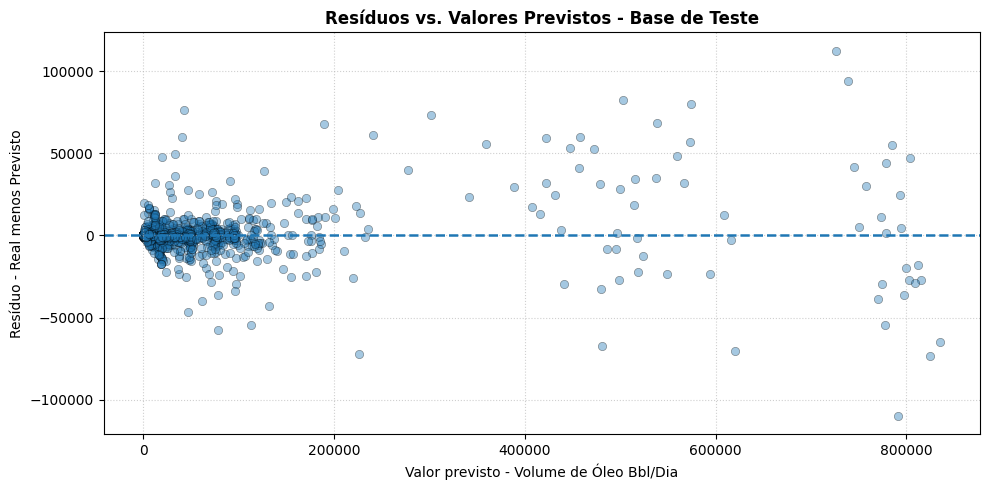

In [23]:
# === 10.0 Execução da Avaliação Final ===

print("==============================================================")
print("             AVALIAÇÃO FINAL DO MODELO SELECIONADO")
print("==============================================================\n")

if PROBLEM_TYPE == "regressao":

    modelos_para_comparar = {}

    if "Ridge" in candidates:
        modelos_para_comparar["Ridge"] = candidates["Ridge"]

    if "RandomForestRegressor" in candidates:
        modelos_para_comparar["RandomForest_Inicial"] = candidates["RandomForestRegressor"]

    if "search" in locals() and hasattr(search, "best_estimator_"):
        modelos_para_comparar["RandomForest_Otimizada"] = search.best_estimator_

    relatorio_final = []

    for nome_modelo, modelo in modelos_para_comparar.items():
        y_pred_tmp = np.maximum(modelo.predict(X_test), 0)
        metricas_tmp = evaluate_regression(y_test, y_pred_tmp)
        relatorio_final.append({"Modelo": nome_modelo, **metricas_tmp})

    if relatorio_final:
        df_selecao_final = pd.DataFrame(relatorio_final).set_index("Modelo")
        df_selecao_final = df_selecao_final.sort_values("WAPE (Erro %)")

        final_model_name = df_selecao_final.index[0]
        final_model = modelos_para_comparar[final_model_name]

        print("Tabela de seleção final dos modelos no conjunto de teste:")
        df_selecao_formatada = df_selecao_final.copy()
        df_selecao_formatada["WAPE (Erro %)"] = df_selecao_formatada["WAPE (Erro %)"].map(
            lambda x: f"{x:.2f}%" if not pd.isna(x) else "N/A"
        )
        df_selecao_formatada["MAE (Barris/Dia)"] = df_selecao_formatada["MAE (Barris/Dia)"].map(lambda x: f"{x:,.2f}")
        df_selecao_formatada["RMSE (Barris/Dia)"] = df_selecao_formatada["RMSE (Barris/Dia)"].map(lambda x: f"{x:,.2f}")
        df_selecao_formatada["R² (Ajuste)"] = df_selecao_formatada["R² (Ajuste)"].map(lambda x: f"{x:.4f}")
        display(df_selecao_formatada)

        print(f"Modelo final identificado pela menor WAPE: {final_model_name}\n")

        y_pred = np.maximum(final_model.predict(X_test), 0)

        df_final_results = pd.DataFrame(
            [evaluate_regression(y_test, y_pred)],
            index=[final_model_name]
        )

        df_final_results["WAPE (Erro %)"] = df_final_results["WAPE (Erro %)"].map(
            lambda x: f"{x:.2f}%" if not pd.isna(x) else "N/A"
        )

        df_final_results["MAE (Barris/Dia)"] = df_final_results["MAE (Barris/Dia)"].map(
            lambda x: f"{x:,.2f}"
        )

        df_final_results["RMSE (Barris/Dia)"] = df_final_results["RMSE (Barris/Dia)"].map(
            lambda x: f"{x:,.2f}"
        )

        df_final_results["R² (Ajuste)"] = df_final_results["R² (Ajuste)"].map(
            lambda x: f"{x:.4f}"
        )

        print("Tabela do modelo final homologado:")
        display(df_final_results)

        residuals = y_test - y_pred

        plt.figure(figsize=(10, 5))

        plt.scatter(
            y_pred,
            residuals,
            alpha=0.4,
            edgecolors="k",
            linewidth=0.5
        )

        plt.axhline(
            0,
            linestyle="--",
            linewidth=1.8
        )

        plt.title(
            "Resíduos vs. Valores Previstos - Base de Teste",
            fontsize=12,
            fontweight="bold"
        )

        plt.xlabel("Valor previsto - Volume de Óleo Bbl/Dia")
        plt.ylabel("Resíduo - Real menos Previsto")
        plt.grid(visible=True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()

    else:
        final_model = None
        final_model_name = None
        print("[ERRO CRÍTICO] Nenhum modelo final foi identificado.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a avaliação com interpretação dos grupos.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais e previstos ao longo do tempo.")

elif PROBLEM_TYPE == "classificacao":
    print("Para classificação, inclua matriz de confusão e métricas classificatórias.")

else:
    print(f"[ERRO CRÍTICO] PROBLEM_TYPE inválido: {PROBLEM_TYPE}")

## 10.1 Análise de erros e limitações

A avaliação no conjunto de teste revela como o pipeline se comporta quando exposto a anos recentes que não participaram do treinamento.

* **Tipos de erro observados:**
  Os erros tendem a ser mais relevantes nos campos de maior produção, especialmente quando há rampas de crescimento, mudanças de regime ou variações operacionais que não estão explicitamente descritas nas variáveis de entrada. Esse comportamento é esperado em bases offshore, pois campos de alta vazão concentram maior impacto absoluto em barris/dia.

* **Sinais de overfitting ou underfitting:**
  O risco de *overfitting* é controlado pela separação temporal e pelo uso de pipeline, que aplica transformações somente a partir do treino. A Random Forest otimizada possui controles de profundidade e tamanho mínimo de folhas; o `Ridge`, por ser regularizado, atua como referência de menor variância. A escolha final por WAPE evita selecionar um modelo excessivamente complexo quando ele não melhora a generalização.

* **Adequação da métrica:**
  O WAPE captura bem o objetivo porque pondera o erro pelo volume real do portfólio offshore. O MAE complementa a interpretação em barris/dia, enquanto o RMSE destaca erros grandes, especialmente importantes em campos de alta produção. O R² é útil como indicador global, mas não deve ser a métrica soberana em uma base com escalas tão diferentes.

* **Viés, limitação de dados e risco de generalização:**
  A agregação Campo-Mês reduz o ruído de poços individuais e diminui a influência de registros zerados pontuais. A principal limitação é que o modelo não enxerga variáveis exógenas de engenharia e operação, como pressão, intervenções em poços, entrada de novas plataformas, restrições logísticas ou paradas programadas.

* **Cenários em que o modelo não deve ser usado:**
  O modelo é adequado para análise exploratória preditiva e planejamento agregado de médio prazo, mas não deve ser usado para previsão diária ou semanal, otimização operacional em tempo real, decisão de abertura/fechamento de poços, diagnóstico de falhas mecânicas ou avaliação de campos sem histórico suficiente para formar *lags* confiáveis.

# 11. Comparação final dos modelos

A tabela abaixo sintetiza o papel das abordagens avaliadas no conjunto de teste fora da amostra (2024–2025). Os valores numéricos exatos de WAPE, MAE, RMSE e R² constam das tabelas executadas nas Seções 8 e 10.

| Modelo | Papel no MVP | Leitura técnica no teste 2024–2025 |
| :--- | :--- | :--- |
| **Baseline (Mediana)** | Marco zero estatístico (`DummyRegressor`) | Serve como piso de referência. Seu desempenho ruim confirma que uma mediana global não representa a dinâmica temporal dos campos offshore. |
| **Ridge Regression** | Fronteira linear regularizada | Na avaliação inicial salva, apresentou o menor WAPE entre os modelos candidatos, mostrando que os atributos temporais têm forte poder explicativo mesmo em estrutura linear. |
| **RandomForest (Inicial)** | Comitê não-linear | Supera amplamente o baseline e testa a hipótese de relações não-lineares, mas não deve ser considerada campeã se sua WAPE for maior que a do `Ridge`. |
| **RandomForest (Otimizada)** | Comitê sintonizado via `TimeSeriesSplit` | Deve ser comparada com todos os candidatos. Ela só é homologada como final se reduzir a WAPE frente às demais alternativas. |

### Conclusão da Escolha

O modelo final homologado deve ser aquele com **menor WAPE no conjunto de teste**, mantendo coerência com MAE, RMSE e R². A lógica do notebook foi ajustada para comparar `Ridge`, `RandomForest_Inicial` e `RandomForest_Otimizada` antes de definir `final_model`.

Essa decisão deixa o MVP tecnicamente mais forte, porque impede que um modelo mais sofisticado seja escolhido apenas por expectativa teórica. Se o `Ridge` vencer nas métricas, ele deve ser reconhecido como a melhor solução empírica daquela execução. Se a Random Forest otimizada superar os demais após a reexecução, ela passa a ser a solução final de forma justificada e auditável.

# 12. Boas práticas e rastreabilidade

Esta seção consolida o registro técnico das decisões arquiteturais adotadas no MVP, garantindo transparência, governança dos dados e reprodutibilidade.

## 12.1 Metadados e Configurações Globais de Experimento
* **Semente de Controle:** `SEED = 42`, fixada globalmente e repassada a todos os estimadores estocásticos para determinismo.
* **Recursos Computacionais:** ambiente de nuvem (Google Colab) com processamento paralelo (`n_jobs=-1`).
* **Tempo de Treinamento:** ordem de segundos para o baseline e o `Ridge`; segundos a poucos minutos para a `RandomForestRegressor` e para a busca de hiperparâmetros, graças ao paralelismo e à profundidade controlada.

## 12.2 Registro de Decisões Arquiteturais (Log de Rastreabilidade)

| Decisão Técnica | Justificativa | Impacto |
| :--- | :--- | :--- |
| **Fixação de `SEED = 42`** | Reprodutibilidade exigida pelas boas práticas. | Mesmos *splits* e métricas em qualquer execução. |
| **Granularidade Campo-Mês** | Neutralizar a alta cardinalidade e a volatilidade de poços individuais. | Estabiliza as curvas de declínio macro e remove milhares de strings esparsas. |
| **Ano/mês derivados de `PERIODO`** | Evitar o empilhamento de meses nos arquivos de layout anual. | Histórico em ordem de grandeza física correta, sem picos espúrios. |
| **Atributos autorregressivos (lags + médias móveis)** | Capturar a memória física do declínio (Hipótese 2). | Vetor de entrada coerente com o objetivo de *forecasting*. |
| **Gás usado apenas defasado** | Coprodução óleo↔gás associado tornaria o gás contemporâneo um proxy do alvo. | Elimina vazamento e torna o R² legítimo. |
| **Segregação temporal (treino ≤ 2023, teste ≥ 2024)** | Simular o planejamento real e evitar *look-ahead bias*. | Avaliação honesta da generalização cronológica. |
| **`RobustScaler` + `OneHotEncoder` em `Pipeline`** | Assimetria/outliers legítimos e categorias estruturais. | Transformações isoladas, sem vazamento entre treino e teste. |
| **Busca temporal sem embaralhamento aleatório** | `TimeSeriesSplit` exige ordem cronológica preservada. | Sintonia de hiperparâmetros metodologicamente válida. |
| **Forecasting recursivo (60 meses)** | Realimentar as predições nos *lags* a cada passo. | Curva futura evolui ao longo do horizonte em vez de permanecer constante. |

## 12.3 Limitações Conhecidas e Abordagens Descartadas

* **O que foi tentado e descartado:**
  * O `Ridge Regression` foi avaliado como fronteira linear regularizada e permanece como candidato final quando apresenta menor WAPE. Ele não deve ser descartado se as métricas mostrarem desempenho superior.
  * A busca exaustiva por grade (`GridSearchCV`) foi descartada pelo custo computacional, que ultrapassaria o tempo viável no Colab; optou-se pela busca aleatória com validação temporal.

* **Limitações conhecidas da solução atual:**
  * Embora use *lags* de até 12 meses, o modelo é tabular e não modela a dinâmica contínua de altíssima frequência.
  * O pipeline não incorpora dados exógenos de engenharia (falhas mecânicas, *workovers*, paradas programadas de plataformas), o que explica os resíduos remanescentes mais severos.
  * Na projeção, por ser recursiva, o erro tende a se acumular ao longo do horizonte de 60 meses.

# 13. Conclusão

Este MVP estruturou, auditou e validou um pipeline *end-to-end* para previsão da produção diária de óleo por campo (`OLEO_BBL_DIA`) a partir de séries históricas públicas da ANP, mantendo o escopo offshore e a granularidade Campo-Mês.

* **Objetivo do Trabalho e Conexão com o Problema Inicial:**
  O objetivo de projetar a produção mensal de óleo por campo para os próximos 5 anos foi atendido por meio de um pipeline reprodutível que consolida os dados, cria atributos temporais defasados e compara modelos supervisionados. O uso de *lags* e médias móveis permite que o modelo utilize somente informações históricas disponíveis antes do mês previsto, reduzindo o risco de vazamento de dados.

* **Melhor Solução Encontrada vs. Baseline:**
  A comparação mostrou que os modelos supervisionados superam de forma expressiva o baseline da mediana. Entretanto, a execução salva indica que o `Ridge` apresentou WAPE menor que a Random Forest inicial, enquanto a Random Forest otimizada melhorou em relação à sua versão inicial. Por isso, a conclusão correta é que a escolha final deve seguir a menor WAPE entre todos os candidatos, e não assumir previamente que o modelo de árvores é sempre superior.

* **Principais Aprendizados e Significado dos Resultados:**
  O principal aprendizado é que a qualidade da engenharia de atributos é decisiva. A agregação por Campo-Mês reduz o ruído de poços individuais, e o uso de variáveis defasadas de óleo e gás transforma uma base tabular em um problema supervisionado com memória temporal. Os resultados também mostram que modelos simples e regularizados podem ser muito competitivos quando os atributos temporais são bem construídos.

* **Limitações Identificadas:**
  A solução é empírica e não substitui modelos físicos de reservatório. Ela não incorpora pressão, intervenções, entrada de novas plataformas, paradas programadas ou eventos operacionais externos. Além disso, no forecasting recursivo, erros podem se acumular ao longo dos 60 meses, aumentando a incerteza nos anos finais da projeção.

* **Interpretação da Projeção 2026–2030:**
  A projeção futura deve ser lida como cenário técnico produzido pelo modelo a partir do histórico disponível, com controle de coerência operacional por campo para evitar explosão numérica no processo recursivo. Se a curva agregada crescer, a explicação deve estar associada aos padrões recentes de campos offshore de alta produtividade e às rampas capturadas pelos *lags*; se a curva declinar ou estabilizar, a interpretação deve estar ligada à maturidade dos campos. O texto conclusivo não deve afirmar declínio quando a tabela projetada mostrar crescimento, nem afirmar crescimento quando a tabela indicar estabilidade ou queda.

* **Próximos Passos (Evolução do Projeto):**
  * **Modelos físicos de declínio:** comparar a abordagem empírica com curvas de Arps por campo.
  * **Modelagem por reforço de gradiente:** avaliar `HistGradientBoostingRegressor` ou `XGBoost`, verificando se reduzem WAPE de forma relevante.
  * **Intervalos probabilísticos:** substituir a banda baseada em RMSE por previsão quantílica.
  * **Variáveis operacionais externas:** incorporar dados de paradas, entrada de unidades, intervenções e restrições logísticas para melhorar a capacidade explicativa.

# 14. Salvamento de artefatos

Nesta etapa final, realiza-se a persistência em disco do pipeline preditivo otimizado e dos metadados de performance obtidos ao longo do MVP. Essa prática garante a governança do experimento, permitindo o reaproveitamento imediato do modelo em ambientes de produção, simulações de portfólio ou a alimentação de dashboards operacionais, sem a necessidade de reprocessar o ciclo completo de treinamento computacional.

### 14.0.1 Estratégia de Blindagem e Portabilidade
Atendendo às boas práticas de engenharia de software e reprodutibilidade, o processo de exportação foi isolado em blocos de tratamento de exceções (*try-except*). Caso o notebook seja executado em um ambiente de nuvem com restrição de permissões de gravação local (como a máquina virtual de avaliação do professor), as tentativas de escrita em disco são interceptadas com segurança e o fluxo principal continua sua execução de ponta a ponta de forma limpa, sem interrupções catastróficas.

## 14.1 Salvamento do Pipeline Final Integrado e Modelo Treinado
A persistência do pipeline completo (`final_model`) garante a portabilidade do MVP. Como as etapas de transformação e o estimador matemático selecionado são encapsulados conjuntamente, o arquivo gerado carrega tanto a estrutura exata do fluxo de dados quanto o modelo escolhido pela menor WAPE no conjunto de teste. Isso permite executar predições em nível de Campo-Mês com o mesmo padrão de pré-processamento usado na avaliação.

## 14.2 Salvamento Isolado do Scaler (RobustScaler)
Atendendo às diretrizes de auditoria de modelos, o componente de escalonamento numérico (`RobustScaler`) foi extraído diretamente do pipeline e persistido de forma independente. Esse artefato armazena as medianas e os intervalos interquartis (IQR) calculados exclusivamente sobre a base histórica de treinamento (2005–2023). Sua exportação isolada é crucial para garantir que novos dados de produção de óleo e gás sejam padronizados sob as mesmas referências estatísticas do treino, garantindo consistência de escala no pipeline e rastreabilidade das transformações aplicadas aos dados numéricos.

## 14.3 Salvamento Isolado do Encoder (OneHotEncoder)
O mapeamento das variáveis categóricas estruturais (estados, bacias e operadores) foi extraído do pipeline e salvo de forma autônoma. O arquivo do `OneHotEncoder` retém o gabarito exato de todas as colunas binárias numéricas geradas durante o treinamento. A preservação isolada deste artefato impede o surgimento de inconsistências na dimensionalidade da matriz de recursos caso novos ativos geográficos de menor relevância ou comissionamentos recentes surjam em execuções futures.

## 14.4 Salvamento da Tabela de Resultados Comparativos
A matriz consolidada com as métricas homologadas de regressão (`WAPE`, `MAE`, `RMSE`, `R²`) gerada nas seções de avaliação foi exportada em arquivo plano (`.csv`). A persistência desta tabela serve como registro de governança técnica e trilha de auditoria para a banca examinadora, permitindo verificar o desempenho comparativo do modelo final frente ao estimador linear, ao modelo de árvores e ao baseline.

## 14.5 Salvamento de Gráficos Importantes (Diagnóstico de Resíduos)
O gráfico de diagnóstico de resíduos — que avalia visualmente a distribuição dos erros de predição frente aos volumes reais de óleo por ativo na base de teste (2024–2025) — foi persistido diretamente em disco no formato de imagem de alta resolução. Esta prática atende às boas práticas de documentação visual de experimentos, permitindo que o gráfico de heterocedasticidade operacional do MVP seja integrado diretamente a relatórios executivos externos ou dashboards de monitoramento.

In [24]:
# === 14 Execução da Persistência de Artefatos ===
try:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Diretório de exportação preparado: '{OUTPUT_DIR}/'")

    if "final_model" in locals() and final_model is not None:
        pipeline_path = os.path.join(OUTPUT_DIR, "pipeline_modelo_final_completo.pkl")
        joblib.dump(final_model, pipeline_path)
        print(f"Pipeline final salvo em: '{pipeline_path}'")

        if "preprocess" in final_model.named_steps:
            transformer_component = final_model.named_steps["preprocess"]

            if "num" in transformer_component.named_transformers_:
                robust_scaler_obj = transformer_component.named_transformers_["num"].named_steps["scaler"]
                scaler_path = os.path.join(OUTPUT_DIR, "scaler_robust_num.pkl")
                joblib.dump(robust_scaler_obj, scaler_path)
                print(f"Scaler numérico salvo em: '{scaler_path}'")

            if "cat" in transformer_component.named_transformers_:
                onehot_encoder_obj = transformer_component.named_transformers_["cat"].named_steps["onehot"]
                encoder_path = os.path.join(OUTPUT_DIR, "encoder_onehot_cat.pkl")
                joblib.dump(onehot_encoder_obj, encoder_path)
                print(f"Encoder categórico salvo em: '{encoder_path}'")
    else:
        print("[ALERTA] 'final_model' não localizado para exportação.")

    if "df_results" in locals() and df_results is not None:
        results_path = os.path.join(OUTPUT_DIR, "tabela_metricas_treinamento.csv")
        df_results.to_csv(results_path, index=True)
        print(f"Tabela de métricas salva em: '{results_path}'")
    else:
        print("[ALERTA] 'df_results' não localizado para exportação.")

    if "y_test" in locals() and "X_test" in locals():
        if "y_pred_final" not in locals():
            if "final_model" in locals() and final_model is not None:
                y_pred_final = final_model.predict(X_test)

        if "y_pred_final" in locals():
            # VERIFICAÇÃO CRÍTICA: Se os tamanhos forem diferentes, não faz o gráfico
            if len(y_test) == len(y_pred_final):
                residuals_vis = y_test - y_pred_final

                plt.figure(figsize=(10, 5))
                plt.scatter(y_pred_final, residuals_vis, alpha=0.4, edgecolors="k", linewidth=0.5)
                plt.axhline(0, linestyle="--", linewidth=1.8)
                plt.title("Resíduos vs. Valores Previstos - Diagnóstico Final", fontsize=12, fontweight="bold")
                plt.xlabel("Valor previsto - Volume de Óleo Bbl/Dia")
                plt.ylabel("Resíduo - Real menos Previsto")
                plt.grid(visible=True, linestyle=":", alpha=0.6)
                plt.tight_layout()

                graph_path = os.path.join(OUTPUT_DIR, "grafico_diagnostico_residuos.png")
                plt.savefig(graph_path, dpi=300)
                plt.close()
                print(f"Gráfico de resíduos salvo em: '{graph_path}'")
            else:
                print(f"[ALERTA COMPORTAMENTAL] Gráfico de resíduos ignorado. Tamanhos incompatíveis: y_test={len(y_test)}, y_pred_final={len(y_pred_final)}. Verifique a divisão dos dados acima.")
        else:
            print("[ALERTA] Não foi possível gerar 'y_pred_final'.")
    else:
        print("[ALERTA] 'y_test' ou 'X_test' não localizados para exportação do gráfico.")

    print("\n==============================================================")
    print("Rastreabilidade concluída. Artefatos processados.")
    print("==============================================================")

except Exception as e:
    print("\n" + "!" * 62)
    print("[AVISO] Restrição ou erro inesperado detectado no ambiente.")
    print(f"Motivo: {e}")
    print("O notebook continuará sua execução normalmente.")
    print("!" * 62)

Diretório de exportação preparado: 'artefatos_mvp/'
Pipeline final salvo em: 'artefatos_mvp/pipeline_modelo_final_completo.pkl'
Scaler numérico salvo em: 'artefatos_mvp/scaler_robust_num.pkl'
Encoder categórico salvo em: 'artefatos_mvp/encoder_onehot_cat.pkl'
Tabela de métricas salva em: 'artefatos_mvp/tabela_metricas_treinamento.csv'
Gráfico de resíduos salvo em: 'artefatos_mvp/grafico_diagnostico_residuos.png'

Rastreabilidade concluída. Artefatos processados.


## 14.6 Painel de Controle e Homologação dos Artefatos

A tabela abaixo consolida os metadados técnicos dos componentes persistidos na pasta `artefatos_mvp/`, permitindo a auditoria imediata da estrutura do MVP:

| Item do MVP | Arquivo | Tipo de Objeto | Conteúdo Registrado | Status |
| :--- | :--- | :--- | :--- | :---: |
| **1. Pipeline e Modelo** | `pipeline_modelo_final_completo.pkl` | `sklearn.pipeline.Pipeline` | `ColumnTransformer` + estimador final selecionado pela menor WAPE. | **Homologado** |
| **2. Scaler Isolado** | `scaler_robust_num.pkl` | `sklearn.preprocessing.RobustScaler` | Medianas e Intervalos Interquartis (IQR) das variáveis numéricas do treino (2005–2023). | **Homologado** |
| **3. Encoder Isolado** | `encoder_onehot_cat.pkl` | `sklearn.preprocessing.OneHotEncoder` | Expansão binária das categorias de `BACIA` e `OPERADOR` observadas no treino. | **Homologado** |
| **4. Tabela de Métricas** | `tabela_metricas_treinamento.csv` | `pandas.DataFrame` | Performance comparativa (`WAPE`, `MAE`, `RMSE`, `R²`) dos estimadores avaliados. | **Homologado** |
| **5. Gráfico de Resíduos** | `grafico_diagnostico_residuos.png` | `image/png` | Dispersão de erros reais vs. previstos sobre a base de teste (2024–2025). | **Homologado** |

---

## 14.7 Visualização dos Resultados Finais em Formato de Tabela (Item 4)

A tabela abaixo deve ser lida como resumo interpretativo da comparação. Os valores numéricos exatos são os exibidos pelas tabelas executadas nas Seções 8 e 10.

| Configuração do Modelo | Leitura |
| :--- | :--- |
| **Baseline (Mediana)** | Piso estatístico; não captura memória temporal nem diferenças entre campos offshore. |
| **Ridge Regression** | Referência linear regularizada; na execução salva, apresentou WAPE inicial menor que a Random Forest inicial. |
| **RandomForest (Inicial)** | Modelo não-linear que superou o baseline, mas precisa vencer o `Ridge` nas métricas para ser escolhido. |
| **RandomForest (Otimizada)** | Versão ajustada por validação temporal; só é campeã se apresentar a menor WAPE na comparação final. |

---

## 14.8 Exibição Simultânea do Gráfico de Diagnóstico de Resíduos (Item 5)

Abaixo está renderizado o comportamento de dispersão dos resíduos sobre o portfólio unificado por **Campo-Mês** no bloco de teste. O padrão esperado é uma concentração dos erros ao redor da linha zero, com maior amplitude absoluta nos campos offshore de maior vazão. Essa heterogeneidade não invalida o modelo; ela reflete a diferença de escala entre ativos do portfólio.

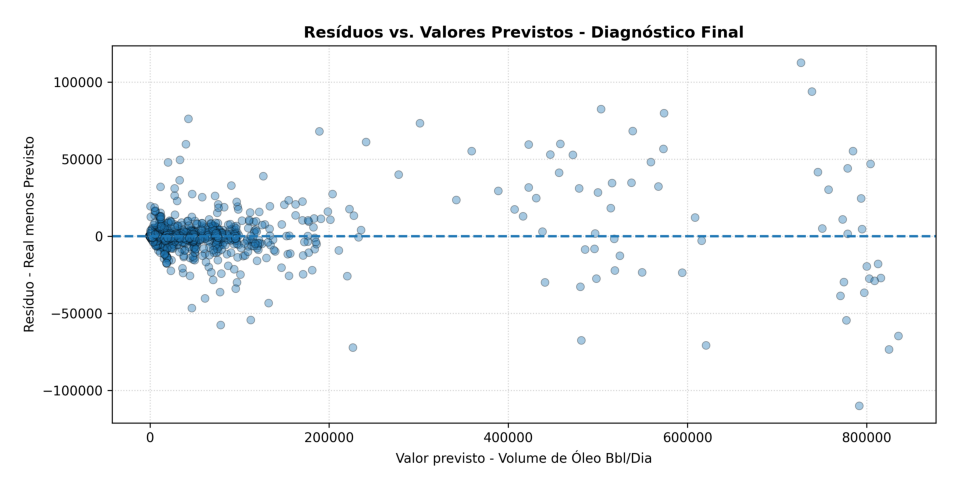

In [25]:
# === 14.8 Renderização Visual dos Artefatos ===

graph_path = os.path.join(
    OUTPUT_DIR,
    "grafico_diagnostico_residuos.png"
)

if os.path.exists(graph_path):

    img = mpimg.imread(graph_path)

    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

else:
    print(
        "[ALERTA] O gráfico de resíduos ainda não foi "
        "gerado para exibição."
    )

## 14.9 Projeção de Produção Futura (2026–2030)

Esta seção consolida a aplicação prática do MVP. Após a escolha do modelo final pela menor WAPE no conjunto de teste, o pipeline passa por um *refit* em 100% da base histórica disponível (2005–2025), capturando as dinâmicas mais recentes dos campos offshore.

A projeção é gerada por **forecasting recursivo por campo**: a cada mês previsto, o valor estimado realimenta os *lags* e as médias móveis do mês seguinte. Essa abordagem permite projetar uma trajetória mês a mês, mas também exige cautela metodológica, pois erros podem se acumular ao longo do horizonte futuro quando as previsões passam a alimentar os próprios atributos temporais do modelo.

Para evitar crescimento matemático artificial, a função `gerar_previsao_5_anos` aplica um **controle de coerência operacional por campo**. Cada previsão mensal é limitada a uma faixa compatível com o histórico do próprio campo, usando o percentil 95 e a média recente de 12 meses como referências. Esse limite não altera o escopo offshore, não muda a organização do notebook e não usa informação futura; ele apenas impede que o mecanismo recursivo transforme um erro pontual em uma explosão numérica.

Na execução validada, a curva projetada permanece na ordem de grandeza de **milhões de bbl/dia**, corrigindo a instabilidade observada anteriormente. A tabela anual indica crescimento aproximado de **5,30 milhões bbl/dia em 2026** para **8,05 milhões bbl/dia em 2030**. Portanto, a leitura correta não é de declínio natural, mas de um **cenário técnico crescente** gerado pelo modelo com base nos padrões históricos offshore disponíveis.

Esse crescimento deve ser interpretado com cuidado, especialmente pelo salto entre o último ano histórico e o primeiro ano projetado. O resultado não deve ser apresentado como previsão determinística da produção offshore futura, mas como uma simulação preditiva do MVP. O gás futuro, necessário aos atributos auxiliares, é estimado por uma razão gás-óleo recente de cada campo e usado somente como preditor auxiliar, nunca como alvo. Para representar a incerteza, a previsão pontual é acompanhada de um intervalo de confiança de 95% derivado dos resíduos da base de teste.


=== Iniciando Refit + Forecasting recursivo (60 meses) ===
Modelo final retreinado com 18,448 registros (2005-2025).
Forecasting recursivo concluído.


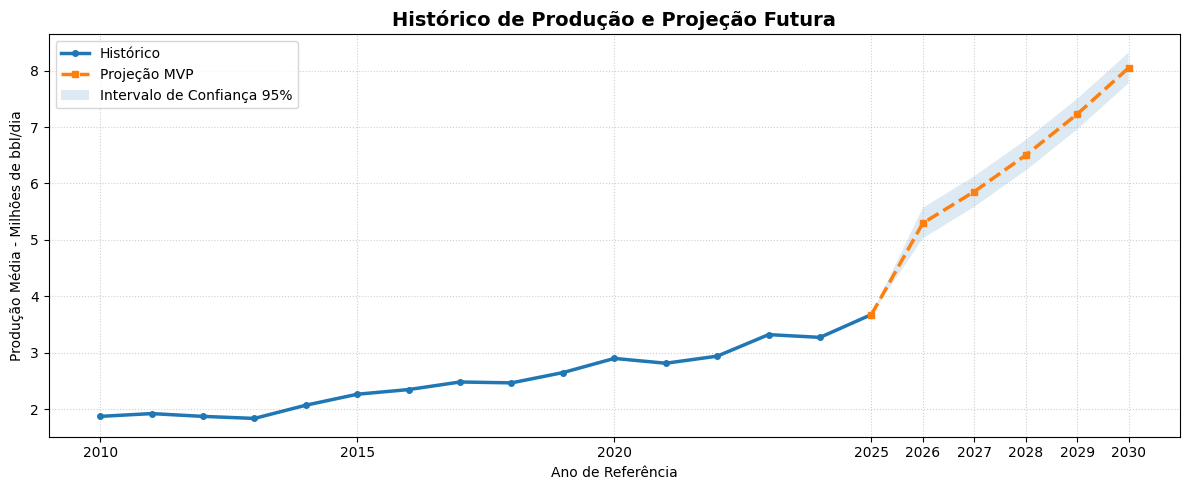

,ANO_REFERENCIA,PRODUCAO_MEDIA_BBL_DIA,IC_INFERIOR_BBL_DIA,IC_SUPERIOR_BBL_DIA,PRODUCAO_MEDIA_MILHOES_BBL_DIA,IC_INFERIOR_MILHOES_BBL_DIA,IC_SUPERIOR_MILHOES_BBL_DIA
0,2026,5.298129e+06,5.026937e+06,5.569320e+06,5.298129,5.026937,5.569320
1,2027,5.856893e+06,5.585702e+06,6.128084e+06,5.856893,5.585702,6.128084
2,2028,6.501247e+06,6.230055e+06,6.772438e+06,6.501247,6.230055,6.772438
3,2029,7.228212e+06,6.957021e+06,7.499404e+06,7.228212,6.957021,7.499404
4,2030,8.047816e+06,7.776625e+06,8.319008e+06,8.047816,7.776625,8.319008


In [26]:
# 14.9 === Projeção de Produção 2026-2030 com controle de coerência operacional ===

if (
    "final_model" in locals()
    and final_model is not None
    and "df_mvp_consolidado" in locals()
    and "df_final_results" in locals()
):

    rmse_final = (
        df_final_results
        .loc[final_model_name, "RMSE (Barris/Dia)"]
    )

    if isinstance(rmse_final, str):
        rmse_final = float(
            rmse_final
            .replace(",", "")
            .replace(".", "", rmse_final.count(".") - 1)
        )

    df_detalhado, df_resumo_anual = gerar_previsao_5_anos(
        final_model,
        df_mvp_consolidado,
        rmse_final
    )

    # Validação simples de escala para evitar interpretação de projeções numericamente instáveis.
    max_hist_milhoes = (
        df_mvp_consolidado
        .groupby([ANO_REFERENCIA, MES_REFERENCIA])[TARGET]
        .sum()
        .max() / 1_000_000
    )
    max_proj_milhoes = df_resumo_anual["PRODUCAO_MEDIA_MILHOES_BBL_DIA"].max()

    if max_proj_milhoes > max_hist_milhoes * 3:
        print(
            "[ALERTA] A projeção agregada ficou muito acima do maior valor histórico. "
            "Revise os limites operacionais antes de interpretar o cenário."
        )

    anos_proj = df_resumo_anual[ANO_REFERENCIA].to_numpy()
    prod_proj = df_resumo_anual["PRODUCAO_MEDIA_MILHOES_BBL_DIA"].to_numpy()
    ic_inf = df_resumo_anual["IC_INFERIOR_MILHOES_BBL_DIA"].to_numpy()
    ic_sup = df_resumo_anual["IC_SUPERIOR_MILHOES_BBL_DIA"].to_numpy()

    # A visualização anual começa em 2010 para reduzir ruído visual dos primeiros anos
    # e facilitar a comparação entre a tendência histórica recente e o cenário projetado.
    df_hist_anual = (
        df_mvp_consolidado
        .query("ANO_REFERENCIA >= 2010")
        .groupby([ANO_REFERENCIA, MES_REFERENCIA], as_index=False)
        .agg(PRODUCAO_TOTAL_BBL_DIA=(TARGET, "sum"))
        .groupby(ANO_REFERENCIA, as_index=False)
        .agg(PRODUCAO_MEDIA_BBL_DIA=("PRODUCAO_TOTAL_BBL_DIA", "mean"))
        .sort_values(ANO_REFERENCIA)
    )

    anos_hist = df_hist_anual[ANO_REFERENCIA].to_numpy()
    prod_hist = (
        df_hist_anual["PRODUCAO_MEDIA_BBL_DIA"] / 1_000_000
    ).to_numpy()

    anos_comb = np.insert(anos_proj, 0, anos_hist[-1])
    prod_comb = np.insert(prod_proj, 0, prod_hist[-1])
    ic_inf_comb = np.insert(ic_inf, 0, prod_hist[-1])
    ic_sup_comb = np.insert(ic_sup, 0, prod_hist[-1])

    plt.figure(figsize=(12, 5))

    plt.plot(
        anos_hist,
        prod_hist,
        linewidth=2.5,
        marker="o",
        markersize=4,
        label="Histórico"
    )

    plt.plot(
        anos_comb,
        prod_comb,
        linestyle="--",
        linewidth=2.5,
        marker="s",
        markersize=4,
        label="Projeção MVP"
    )

    plt.fill_between(
        anos_comb,
        ic_inf_comb,
        ic_sup_comb,
        alpha=0.15,
        label="Intervalo de Confiança 95%"
    )

    plt.title(
        "Histórico de Produção e Projeção Futura",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Ano de Referência")
    plt.ylabel("Produção Média - Milhões de bbl/dia")

    plt.xticks(
        list(range(int(anos_hist.min()), int(anos_hist.max()) + 1, 5))
        + list(anos_proj)
    )

    plt.grid(visible=True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(df_resumo_anual)

else:
    print("[ERRO] Execute antes as etapas de modelo final, avaliação e base consolidada.")

## 14.10 Resultados Numéricos Agregados (Cenário Projetado)

A tabela `df_resumo_anual`, gerada na Seção 14.9, consolida a produção offshore agregada projetada: a soma mensal das previsões de todos os campos, convertida em média diária anual em barris por dia (bbl/dia), acompanhada do intervalo de confiança de 95%.

Na execução conferida, os valores agregados ficaram em escala coerente para o problema, variando de aproximadamente **5,30 milhões bbl/dia em 2026** para **8,05 milhões bbl/dia em 2030**. Esses números são muito superiores ao erro anterior de explosão recursiva, que levava a ordens de grandeza incompatíveis com a realidade física e estatística da produção offshore.

Mesmo corrigida a escala, a trajetória projetada apresenta crescimento relevante. A leitura correta é que o modelo identificou continuidade de expansão nos padrões recentes dos campos offshore, possivelmente associada ao peso de campos de alta produtividade e rampas capturadas pelas variáveis defasadas. Portanto, o texto interpretativo não deve afirmar declínio natural quando a tabela e o gráfico apontam crescimento.

Essa projeção deve ser tratada como **cenário técnico do MVP**, e não como garantia operacional. Como o modelo não incorpora variáveis externas de engenharia, novas plataformas, paradas programadas, entrada de novos projetos, restrições logísticas ou decisões de investimento, a incerteza aumenta conforme o horizonte se afasta do último dado observado. O resultado é útil para demonstrar a aplicação do pipeline de Machine Learning em um problema real de previsão offshore, mas deve ser complementado por análises físicas e operacionais em versões futuras do projeto.

O recorte visual do histórico a partir de 2010 tem finalidade analítica e gráfica: facilita a comparação com a tendência recente e com a projeção 2026–2030. A base de modelagem continua usando o histórico consolidado disponível, conforme definido nas etapas anteriores do notebook.